# 🧠 Deep Learning Final Project — CNN Image Classification

> Complete implementation covering all three parts:
> - **Part 1:** Training CNNs from Scratch (Steps 1-3)
> - **Part 2:** Transfer Learning with Your Own Pretrained Model (Steps 4-5)
> - **Part 3:** Transfer Learning with ResNet50 (Steps 6-7)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================================
# IMPORTS AND SETUP
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


---
# 📦 PART 1 — Training a CNN from Scratch

> **Goal:** Build and train CNN architectures from scratch, comparing different architectures, optimizers, and hyperparameters.

## 🔧 Step 1 — Architecture & Optimization

### 1.1 Data Setup

In [ ]:
# ============================================================================
# 1.1 DATA LOADING AND PREPARATION
# ============================================================================

DATA_PATH = '/content/drive/MyDrive/data'

# Define transforms for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the entire dataset
full_dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)

# Get class names and number of classes
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Total images: {len(full_dataset)}")

# Define split ratios (70/15/15)
train_ratio, valid_ratio, test_ratio = 0.7, 0.15, 0.15

# Calculate split sizes
total_size = len(full_dataset)
train_size = int(train_ratio * total_size)
valid_size = int(valid_ratio * total_size)
test_size = total_size - train_size - valid_size

# Split the dataset
train_dataset, valid_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, valid_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nDataset splits:")
print(f"  Train: {len(train_dataset)}")
print(f"  Valid: {len(valid_dataset)}")
print(f"  Test:  {len(test_dataset)}")

Classes: ['COLE', 'DBRMN', 'GRDNSTR', 'GRMNSHP', 'GRNDL', 'MLNS', 'RTWLR']
Number of classes: 7
Total images: 1069

Dataset splits:
  Train: 748
  Valid: 160
  Test:  161


In [ ]:
# Create DataLoaders
def create_dataloaders(batch_size=64):
    """Create train, validation, and test DataLoaders."""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

# Default batch size
BATCH_SIZE = 64
train_loader, valid_loader, test_loader = create_dataloaders(BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 64
Training batches: 12
Validation batches: 3
Test batches: 3


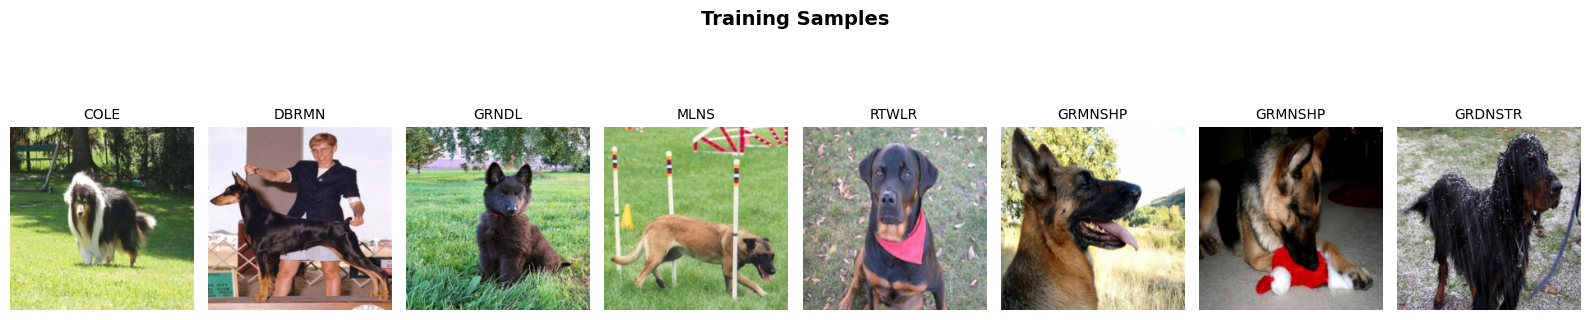

In [ ]:
# Visualize sample images
def visualize_samples(dataset, n_samples=8, title="Sample Images"):
    """Visualize sample images from the dataset."""
    fig, axes = plt.subplots(1, n_samples, figsize=(16, 4))

    # Get random samples
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        # Denormalize for visualization
        img = img.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(class_names[label], fontsize=10)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset, title="Training Samples")

### 1.2 CNN Architectures

**Architecture A (Shallow CNN):** 2 convolutional layers + 2 FC layers
- Simpler model, fewer parameters, faster training
- Good baseline, may underfit on complex data

**Architecture B (Deep CNN):** 4 convolutional layers + 3 FC layers  
- More capacity to learn complex features
- May overfit on small datasets, needs regularization

In [ ]:
# ============================================================================
# 1.2 CNN ARCHITECTURES
# ============================================================================

class ShallowCNN(nn.Module):
    """
    Architecture A: Shallow CNN
    2 Conv layers + 2 FC layers
    Input: 224x224 RGB images → Output: num_classes
    """
    def __init__(self, num_classes=7):
        super(ShallowCNN, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 → 112

            # Conv2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 → 56
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN(nn.Module):
    """
    Architecture B: Deep CNN
    4 Conv layers + 3 FC layers
    Input: 224x224 RGB images → Output: num_classes
    """
    def __init__(self, num_classes=7):
        super(DeepCNN, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 → 112

            # Conv2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 → 56

            # Conv3: 64 → 128 channels
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 → 28

            # Conv4: 128 → 32 channels
            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 → 14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Verify architectures
def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

shallow_model = ShallowCNN(num_classes)
deep_model = DeepCNN(num_classes)

print("=" * 50)
print("SHALLOW CNN ARCHITECTURE")
print("=" * 50)
print(f"Total parameters: {count_parameters(shallow_model):,}")
print(shallow_model)

print("\n" + "=" * 50)
print("DEEP CNN ARCHITECTURE")
print("=" * 50)
print(f"Total parameters: {count_parameters(deep_model):,}")
print(deep_model)

SHALLOW CNN ARCHITECTURE
Total parameters: 25,744,839
ShallowCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)

DEEP CNN ARCHITECTURE
Total parameters: 1,168,359
DeepCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
   

### 1.3 Training Loop and Utilities

In [ ]:
# ============================================================================
# TRAINING UTILITIES
# ============================================================================

def train_model(model, train_loader, valid_loader, optimizer, num_epochs=10,
                scheduler=None, verbose=True):
    """
    Train a PyTorch model with training and validation loops.

    Args:
        model: PyTorch model to train
        train_loader: Training DataLoader
        valid_loader: Validation DataLoader
        optimizer: PyTorch optimizer
        num_epochs: Number of training epochs
        scheduler: Learning rate scheduler (optional)
        verbose: Print progress if True

    Returns:
        history: dict with train/valid loss and accuracy per epoch
    """
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        'train_loss': [], 'valid_loss': [],
        'train_acc': [], 'valid_acc': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        # Validation phase
        model.eval()
        valid_loss, valid_correct, valid_total = 0.0, 0, 0

        with torch.no_grad():
            for x_batch, y_batch in valid_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = loss_fn(outputs, y_batch)

                valid_loss += loss.item() * x_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                valid_total += y_batch.size(0)
                valid_correct += (predicted == y_batch).sum().item()

        # Calculate metrics
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_valid_loss = valid_loss / valid_total
        epoch_valid_acc = valid_correct / valid_total

        # Store history
        history['train_loss'].append(epoch_train_loss)
        history['valid_loss'].append(epoch_valid_loss)
        history['train_acc'].append(epoch_train_acc)
        history['valid_acc'].append(epoch_valid_acc)

        # Learning rate scheduler step
        if scheduler:
            scheduler.step()

        # Print progress
        if verbose:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} - "
                  f"Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}")

    training_time = time.time() - start_time
    history['training_time'] = training_time

    if verbose:
        print(f"\nTotal training time: {training_time:.2f}s")

    return history


def evaluate_model(model, test_loader):
    """Evaluate model on test set."""
    model = model.to(device)
    model.eval()

    test_correct, test_total = 0, 0
    all_predictions, all_labels = [], []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)

            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = test_correct / test_total
    return accuracy, all_predictions, all_labels


def plot_training_history(history, title="Training History"):
    """Plot training and validation curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['valid_loss'], label='Valid Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['valid_acc'], label='Valid Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_comparison(histories, labels, title="Model Comparison"):
    """Plot comparison of multiple training histories."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for i, (hist, label) in enumerate(zip(histories, labels)):
        # Training Loss
        axes[0, 0].plot(hist['train_loss'], label=label, color=colors[i], marker='o')
        # Validation Loss
        axes[0, 1].plot(hist['valid_loss'], label=label, color=colors[i], marker='s')
        # Training Accuracy
        axes[1, 0].plot(hist['train_acc'], label=label, color=colors[i], marker='o')
        # Validation Accuracy
        axes[1, 1].plot(hist['valid_acc'], label=label, color=colors[i], marker='s')

    titles = ['Training Loss', 'Validation Loss', 'Training Accuracy', 'Validation Accuracy']
    ylabels = ['Loss', 'Loss', 'Accuracy', 'Accuracy']

    for idx, ax in enumerate(axes.flat):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabels[idx])
        ax.set_title(titles[idx], fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_compare(history1, history2, label1='Experiment 1', label2='Experiment 2',
                 title_prefix='Comparison'):
    """
    Plot side-by-side comparison of two training histories.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss comparison
    axes[0].plot(history1['train_loss'], label=f'Train Loss ({label1})', marker='o')
    axes[0].plot(history1['valid_loss'], label=f'Valid Loss ({label1})', marker='s')
    axes[0].plot(history2['train_loss'], label=f'Train Loss ({label2})', marker='o', linestyle='--')
    axes[0].plot(history2['valid_loss'], label=f'Valid Loss ({label2})', marker='s', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title_prefix}: Loss')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Accuracy comparison
    axes[1].plot(history1['train_acc'], label=f'Train Acc ({label1})', marker='o')
    axes[1].plot(history1['valid_acc'], label=f'Valid Acc ({label1})', marker='s')
    axes[1].plot(history2['train_acc'], label=f'Train Acc ({label2})', marker='o', linestyle='--')
    axes[1].plot(history2['valid_acc'], label=f'Valid Acc ({label2})', marker='s', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title_prefix}: Accuracy')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Training utilities defined successfully!")

Training utilities defined successfully!


### 1.4 Optimizer Comparison: Adam vs SGD

In [ ]:
# ============================================================================
# 1.4 OPTIMIZER COMPARISON: SHALLOW CNN
# ============================================================================

NUM_EPOCHS = 15
LR = 0.001

# Train Shallow CNN with SGD
print("Training Shallow CNN with SGD + Momentum...")
shallow_sgd = ShallowCNN(num_classes)
optimizer_sgd = optim.SGD(shallow_sgd.parameters(), lr=LR, momentum=0.9)
history_shallow_sgd = train_model(shallow_sgd, train_loader, valid_loader,
                                   optimizer_sgd, num_epochs=NUM_EPOCHS)

Training Shallow CNN with SGD + Momentum...
Epoch [1/15] - Train Loss: 1.9381, Train Acc: 0.1604 - Valid Loss: 1.9076, Valid Acc: 0.2188
Epoch [2/15] - Train Loss: 1.8498, Train Acc: 0.2620 - Valid Loss: 1.8619, Valid Acc: 0.2812
Epoch [3/15] - Train Loss: 1.7226, Train Acc: 0.3422 - Valid Loss: 1.8517, Valid Acc: 0.2313
Epoch [4/15] - Train Loss: 1.6204, Train Acc: 0.3476 - Valid Loss: 1.8638, Valid Acc: 0.2875
Epoch [5/15] - Train Loss: 1.5327, Train Acc: 0.4171 - Valid Loss: 1.8887, Valid Acc: 0.2313
Epoch [6/15] - Train Loss: 1.4938, Train Acc: 0.4291 - Valid Loss: 1.8710, Valid Acc: 0.2313
Epoch [7/15] - Train Loss: 1.3696, Train Acc: 0.4840 - Valid Loss: 1.9349, Valid Acc: 0.2437
Epoch [8/15] - Train Loss: 1.2627, Train Acc: 0.5455 - Valid Loss: 1.9953, Valid Acc: 0.2188
Epoch [9/15] - Train Loss: 1.1490, Train Acc: 0.5936 - Valid Loss: 1.9422, Valid Acc: 0.2562
Epoch [10/15] - Train Loss: 0.9622, Train Acc: 0.6832 - Valid Loss: 2.1753, Valid Acc: 0.2437
Epoch [11/15] - Train Los

In [ ]:
# Train Shallow CNN with Adam
print("Training Shallow CNN with Adam...")
shallow_adam = ShallowCNN(num_classes)
optimizer_adam = optim.Adam(shallow_adam.parameters(), lr=LR)
history_shallow_adam = train_model(shallow_adam, train_loader, valid_loader,
                                    optimizer_adam, num_epochs=NUM_EPOCHS)

Training Shallow CNN with Adam...
Epoch [1/15] - Train Loss: 6.0043, Train Acc: 0.1631 - Valid Loss: 1.9420, Valid Acc: 0.1812
Epoch [2/15] - Train Loss: 1.9482, Train Acc: 0.1457 - Valid Loss: 1.9423, Valid Acc: 0.1812
Epoch [3/15] - Train Loss: 1.9478, Train Acc: 0.1457 - Valid Loss: 1.9422, Valid Acc: 0.1812
Epoch [4/15] - Train Loss: 1.9383, Train Acc: 0.1484 - Valid Loss: 1.9399, Valid Acc: 0.1500
Epoch [5/15] - Train Loss: 1.8895, Train Acc: 0.2086 - Valid Loss: 1.9002, Valid Acc: 0.2188
Epoch [6/15] - Train Loss: 1.7126, Train Acc: 0.3676 - Valid Loss: 1.9704, Valid Acc: 0.1938
Epoch [7/15] - Train Loss: 1.4281, Train Acc: 0.4920 - Valid Loss: 1.9598, Valid Acc: 0.2062
Epoch [8/15] - Train Loss: 0.9671, Train Acc: 0.6778 - Valid Loss: 2.3656, Valid Acc: 0.2437
Epoch [9/15] - Train Loss: 0.5128, Train Acc: 0.8650 - Valid Loss: 3.1578, Valid Acc: 0.2437
Epoch [10/15] - Train Loss: 0.2195, Train Acc: 0.9385 - Valid Loss: 3.7636, Valid Acc: 0.2250
Epoch [11/15] - Train Loss: 0.0827,

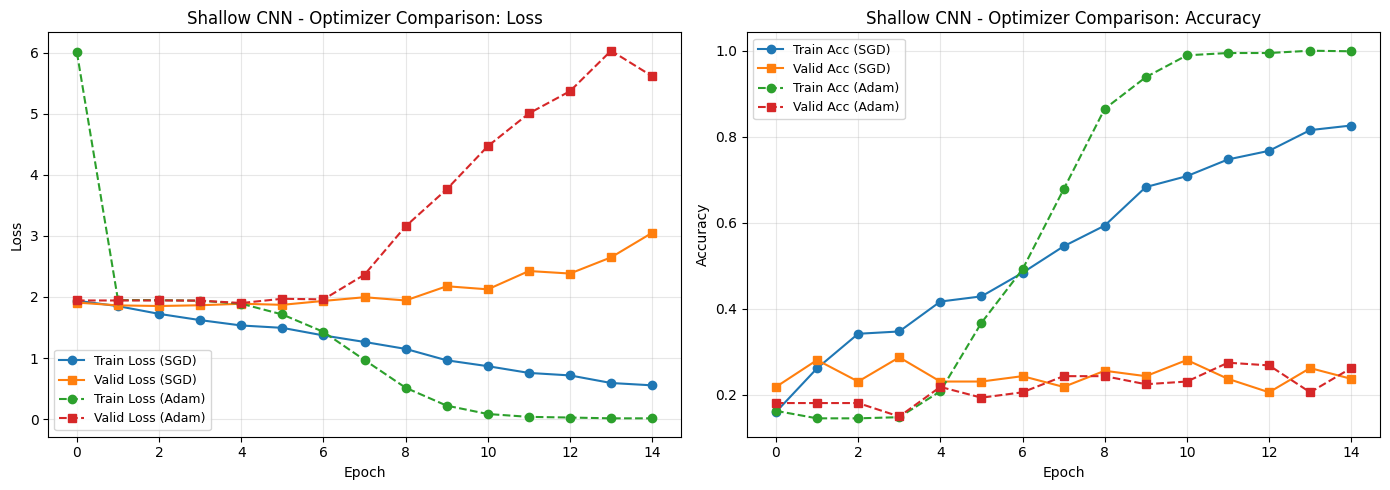

In [ ]:
# Plot Shallow CNN optimizer comparison
plot_compare(history_shallow_sgd, history_shallow_adam,
             label1='SGD', label2='Adam',
             title_prefix='Shallow CNN - Optimizer Comparison')

In [ ]:
# ============================================================================
# 1.4 OPTIMIZER COMPARISON: DEEP CNN
# ============================================================================

# Train Deep CNN with SGD
print("Training Deep CNN with SGD + Momentum...")
deep_sgd = DeepCNN(num_classes)
optimizer_sgd = optim.SGD(deep_sgd.parameters(), lr=LR, momentum=0.9)
history_deep_sgd = train_model(deep_sgd, train_loader, valid_loader,
                                optimizer_sgd, num_epochs=NUM_EPOCHS)

Training Deep CNN with SGD + Momentum...
Epoch [1/15] - Train Loss: 1.9450, Train Acc: 0.1564 - Valid Loss: 1.9502, Valid Acc: 0.1250
Epoch [2/15] - Train Loss: 1.9448, Train Acc: 0.1564 - Valid Loss: 1.9500, Valid Acc: 0.1250
Epoch [3/15] - Train Loss: 1.9446, Train Acc: 0.1537 - Valid Loss: 1.9497, Valid Acc: 0.1313
Epoch [4/15] - Train Loss: 1.9444, Train Acc: 0.1551 - Valid Loss: 1.9495, Valid Acc: 0.1313
Epoch [5/15] - Train Loss: 1.9441, Train Acc: 0.1591 - Valid Loss: 1.9493, Valid Acc: 0.1313
Epoch [6/15] - Train Loss: 1.9440, Train Acc: 0.1658 - Valid Loss: 1.9489, Valid Acc: 0.1437
Epoch [7/15] - Train Loss: 1.9436, Train Acc: 0.1711 - Valid Loss: 1.9486, Valid Acc: 0.1437
Epoch [8/15] - Train Loss: 1.9434, Train Acc: 0.1818 - Valid Loss: 1.9485, Valid Acc: 0.1437
Epoch [9/15] - Train Loss: 1.9430, Train Acc: 0.1885 - Valid Loss: 1.9479, Valid Acc: 0.1562
Epoch [10/15] - Train Loss: 1.9426, Train Acc: 0.1965 - Valid Loss: 1.9476, Valid Acc: 0.1562
Epoch [11/15] - Train Loss: 

In [ ]:
# Train Deep CNN with Adam
print("Training Deep CNN with Adam...")
deep_adam = DeepCNN(num_classes)
optimizer_adam = optim.Adam(deep_adam.parameters(), lr=LR)
history_deep_adam = train_model(deep_adam, train_loader, valid_loader,
                                 optimizer_adam, num_epochs=NUM_EPOCHS)

Training Deep CNN with Adam...
Epoch [1/15] - Train Loss: 1.9368, Train Acc: 0.1444 - Valid Loss: 1.9236, Valid Acc: 0.2062
Epoch [2/15] - Train Loss: 1.8749, Train Acc: 0.2340 - Valid Loss: 1.8604, Valid Acc: 0.2375
Epoch [3/15] - Train Loss: 1.8338, Train Acc: 0.2513 - Valid Loss: 1.8367, Valid Acc: 0.2938
Epoch [4/15] - Train Loss: 1.7374, Train Acc: 0.2527 - Valid Loss: 1.7474, Valid Acc: 0.3312
Epoch [5/15] - Train Loss: 1.7211, Train Acc: 0.2955 - Valid Loss: 1.8083, Valid Acc: 0.2875
Epoch [6/15] - Train Loss: 1.6390, Train Acc: 0.3436 - Valid Loss: 1.7322, Valid Acc: 0.3250
Epoch [7/15] - Train Loss: 1.5408, Train Acc: 0.3890 - Valid Loss: 1.7258, Valid Acc: 0.3125
Epoch [8/15] - Train Loss: 1.4680, Train Acc: 0.4372 - Valid Loss: 1.7739, Valid Acc: 0.3688
Epoch [9/15] - Train Loss: 1.2882, Train Acc: 0.5013 - Valid Loss: 2.0404, Valid Acc: 0.2875
Epoch [10/15] - Train Loss: 1.0878, Train Acc: 0.5963 - Valid Loss: 2.4082, Valid Acc: 0.2625
Epoch [11/15] - Train Loss: 0.8204, Tr

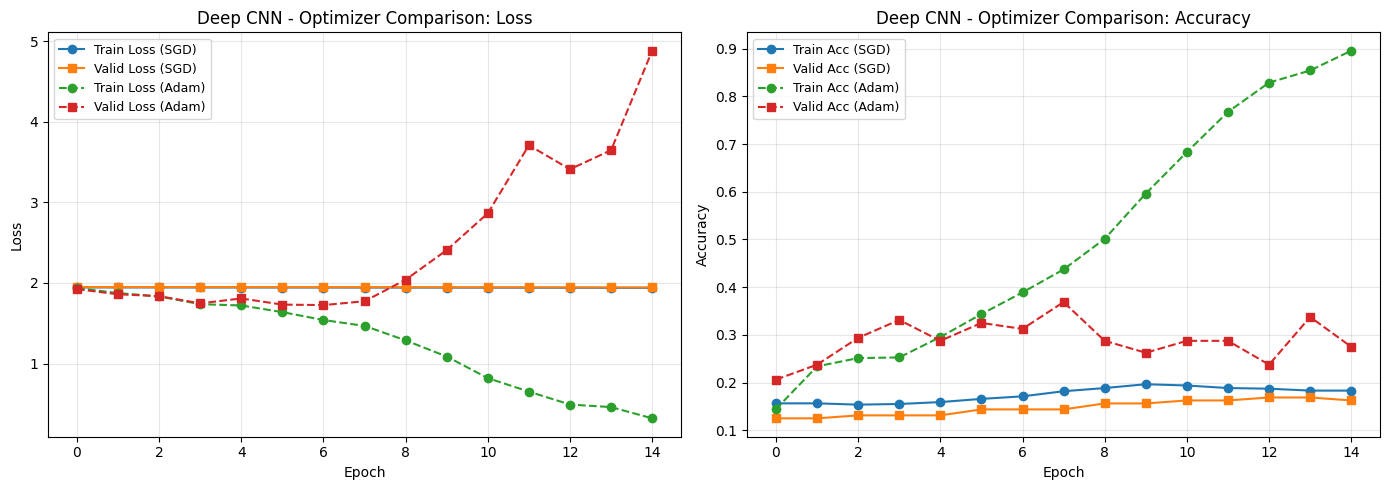

In [ ]:
# Plot Deep CNN optimizer comparison
plot_compare(history_deep_sgd, history_deep_adam,
             label1='SGD', label2='Adam',
             title_prefix='Deep CNN - Optimizer Comparison')

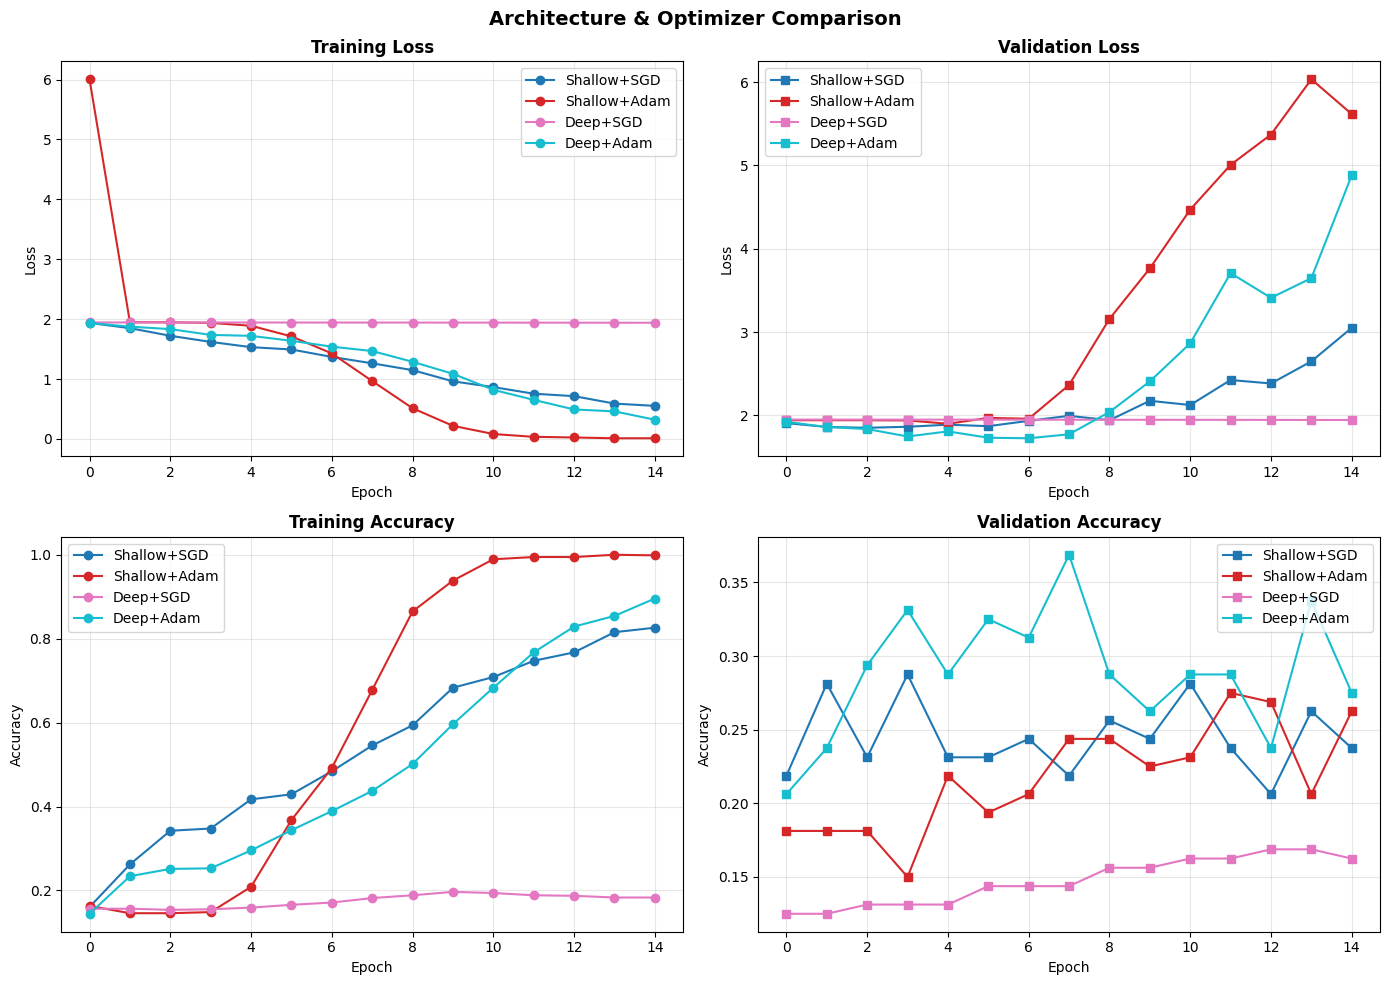

In [ ]:
# Compare all models
all_histories = [history_shallow_sgd, history_shallow_adam, history_deep_sgd, history_deep_adam]
all_labels = ['Shallow+SGD', 'Shallow+Adam', 'Deep+SGD', 'Deep+Adam']
plot_comparison(all_histories, all_labels, title="Architecture & Optimizer Comparison")

### 1.5 Hyperparameter Tuning: Learning Rate

In [ ]:
# ============================================================================
# 1.5 LEARNING RATE EXPERIMENTS
# ============================================================================

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_histories = []

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Training with learning rate: {lr}")
    print(f"{'='*50}")

    model = ShallowCNN(num_classes)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = train_model(model, train_loader, valid_loader, optimizer,
                          num_epochs=10, verbose=False)
    lr_histories.append(history)

    print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")

print("\nLearning rate experiments completed!")


Training with learning rate: 0.1
Final Valid Acc: 0.1688

Training with learning rate: 0.01
Final Valid Acc: 0.2437

Training with learning rate: 0.001
Final Valid Acc: 0.2437

Training with learning rate: 0.0001
Final Valid Acc: 0.2875

Learning rate experiments completed!


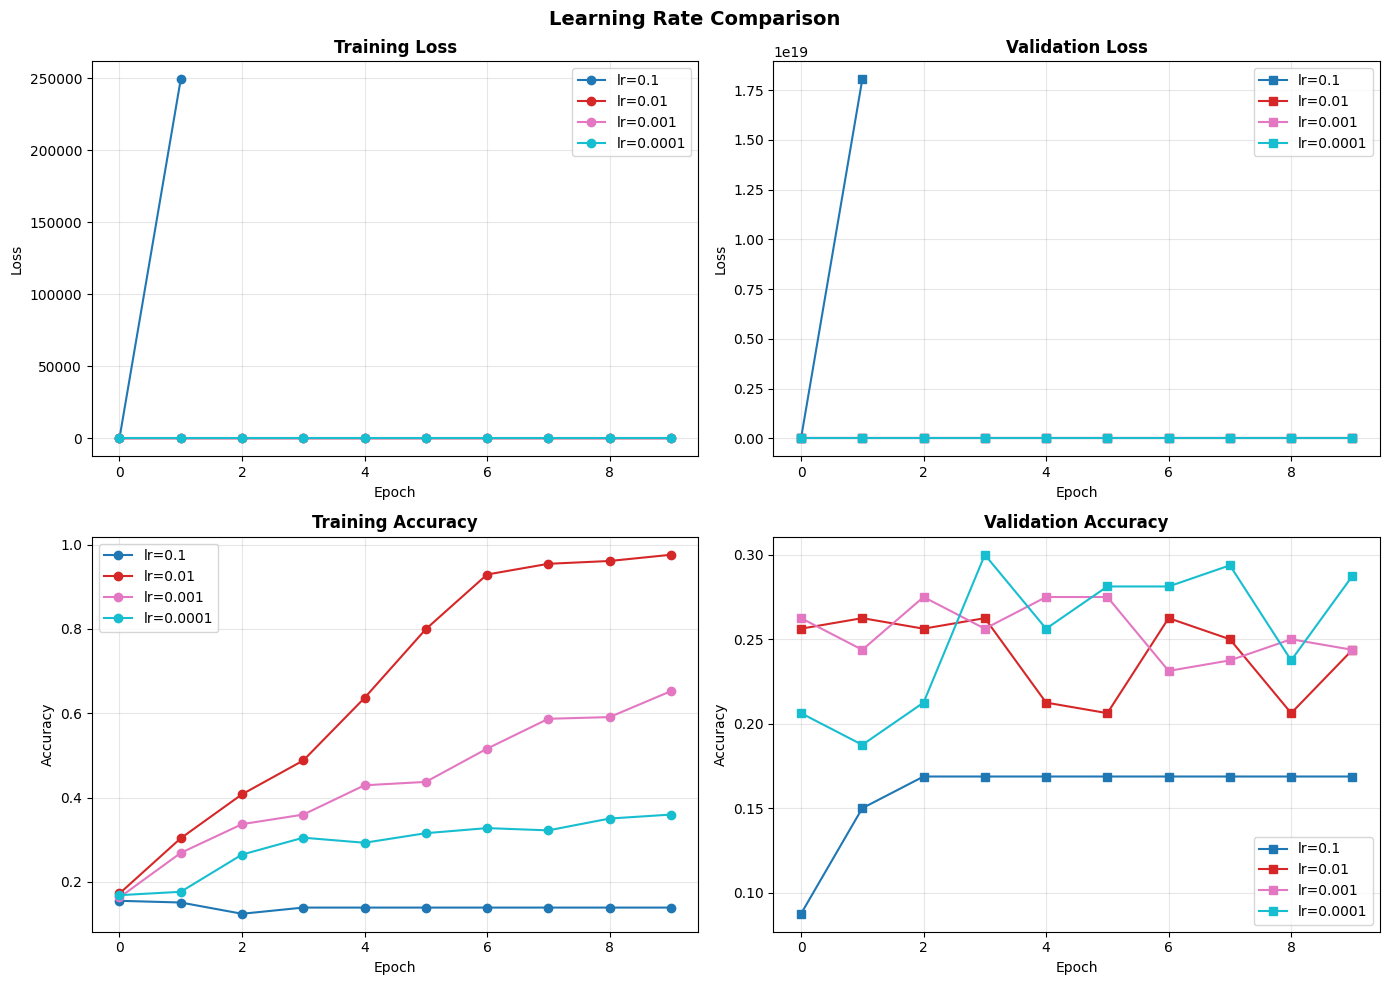

In [ ]:
# Plot learning rate comparison
plot_comparison(lr_histories, [f'lr={lr}' for lr in learning_rates],
                title="Learning Rate Comparison")

### 1.6 Hyperparameter Tuning: Batch Size

In [ ]:
# ============================================================================
# 1.6 BATCH SIZE EXPERIMENTS
# ============================================================================

batch_sizes = [16, 32, 64, 128]
bs_histories = []

for bs in batch_sizes:
    print(f"\n{'='*50}")
    print(f"Training with batch size: {bs}")
    print(f"{'='*50}")

    train_dl, valid_dl, test_dl = create_dataloaders(batch_size=bs)

    model = ShallowCNN(num_classes)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    history = train_model(model, train_dl, valid_dl, optimizer,
                          num_epochs=10, verbose=False)
    bs_histories.append(history)

    print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")
    print(f"Training time: {history['training_time']:.2f}s")

print("\nBatch size experiments completed!")


Training with batch size: 16
Final Valid Acc: 0.2625
Training time: 80.03s

Training with batch size: 32
Final Valid Acc: 0.3063
Training time: 79.13s

Training with batch size: 64
Final Valid Acc: 0.2062
Training time: 76.74s

Training with batch size: 128
Final Valid Acc: 0.2938
Training time: 75.94s

Batch size experiments completed!


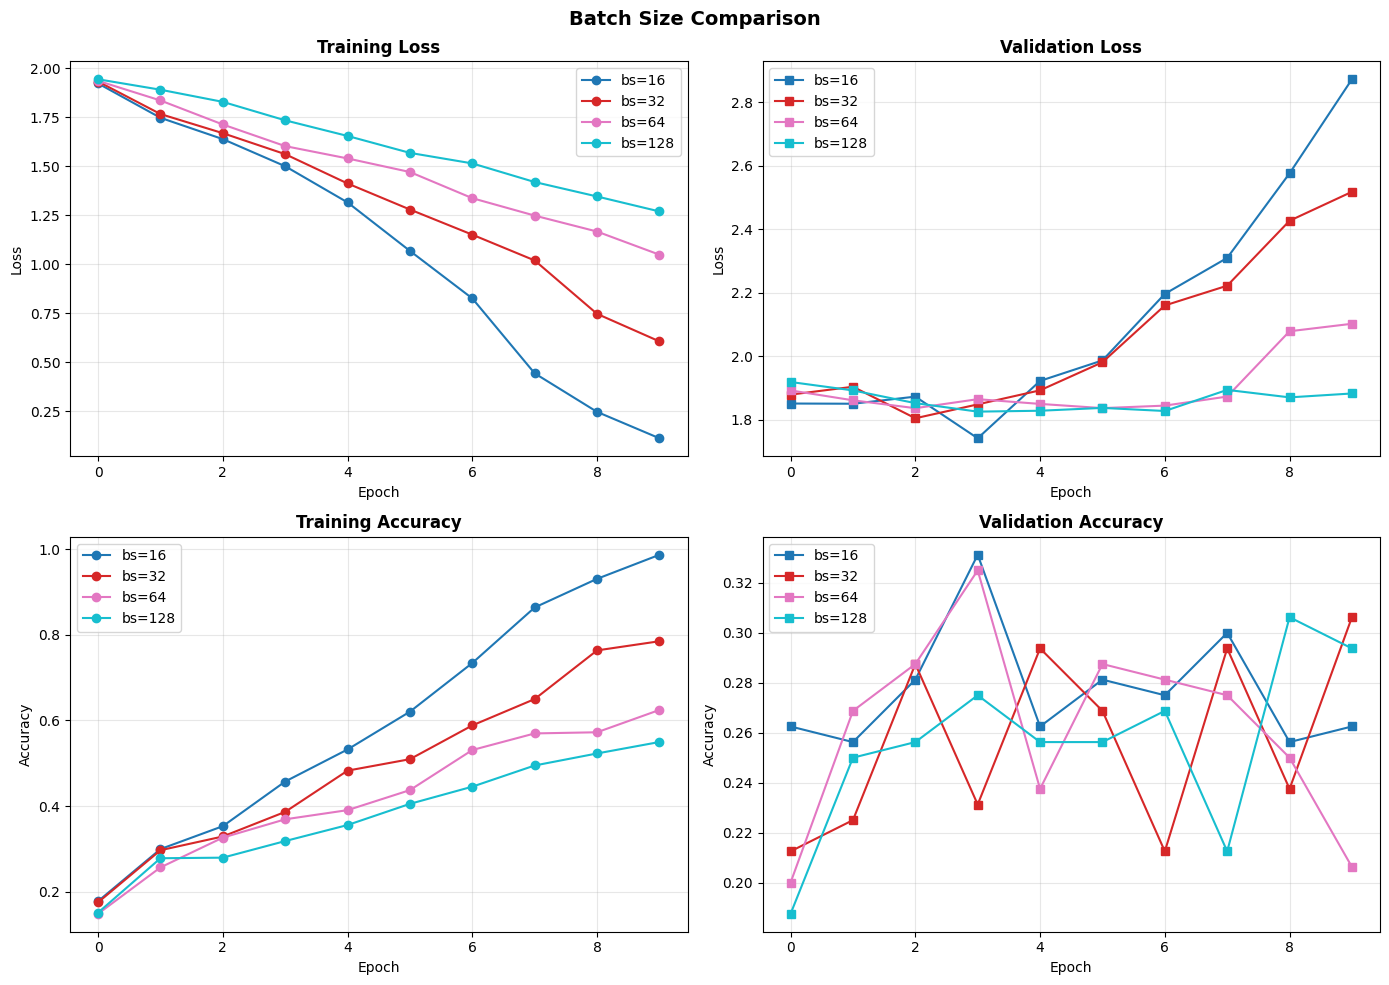

In [ ]:
# Plot batch size comparison
plot_comparison(bs_histories, [f'bs={bs}' for bs in batch_sizes],
                title="Batch Size Comparison")

---
## 📊 Step 2 — Batch Normalization

> **Goal:** Add Batch Normalization to improve training stability and convergence speed.

In [ ]:
# ============================================================================
# STEP 2: CNN WITH BATCH NORMALIZATION
# ============================================================================

class ShallowCNN_BN(nn.Module):
    """
    Shallow CNN with Batch Normalization
    Order: Conv → BatchNorm → ReLU → Pool
    """
    def __init__(self, num_classes=7):
        super(ShallowCNN_BN, self).__init__()

        self.features = nn.Sequential(
            # Conv1 + BN
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2 + BN
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN_BN(nn.Module):
    """
    Deep CNN with Batch Normalization
    Order: Conv → BatchNorm → ReLU → Pool
    """
    def __init__(self, num_classes=7):
        super(DeepCNN_BN, self).__init__()

        self.features = nn.Sequential(
            # Conv1 + BN
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2 + BN
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3 + BN
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv4 + BN
            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("BatchNorm architectures defined!")
print(f"ShallowCNN_BN parameters: {count_parameters(ShallowCNN_BN(num_classes)):,}")
print(f"DeepCNN_BN parameters: {count_parameters(DeepCNN_BN(num_classes)):,}")

BatchNorm architectures defined!
ShallowCNN_BN parameters: 25,745,287
DeepCNN_BN parameters: 1,169,191


In [ ]:
# Train models with and without BatchNorm for comparison
print("Training Shallow CNN WITHOUT BatchNorm...")
shallow_no_bn = ShallowCNN(num_classes)
optimizer = optim.SGD(shallow_no_bn.parameters(), lr=0.01, momentum=0.9)
history_no_bn = train_model(shallow_no_bn, train_loader, valid_loader, optimizer, num_epochs=15)

Training Shallow CNN WITHOUT BatchNorm...
Epoch [1/15] - Train Loss: 1.9049, Train Acc: 0.1818 - Valid Loss: 1.8342, Valid Acc: 0.2188
Epoch [2/15] - Train Loss: 1.6817, Train Acc: 0.3503 - Valid Loss: 1.8827, Valid Acc: 0.3187
Epoch [3/15] - Train Loss: 1.5767, Train Acc: 0.4131 - Valid Loss: 1.8179, Valid Acc: 0.3125
Epoch [4/15] - Train Loss: 1.3686, Train Acc: 0.4920 - Valid Loss: 1.9401, Valid Acc: 0.2938
Epoch [5/15] - Train Loss: 1.0667, Train Acc: 0.6337 - Valid Loss: 1.9978, Valid Acc: 0.2812
Epoch [6/15] - Train Loss: 0.6455, Train Acc: 0.7955 - Valid Loss: 2.7547, Valid Acc: 0.2313
Epoch [7/15] - Train Loss: 0.2666, Train Acc: 0.8944 - Valid Loss: 4.2994, Valid Acc: 0.2500
Epoch [8/15] - Train Loss: 0.1366, Train Acc: 0.9626 - Valid Loss: 4.3377, Valid Acc: 0.2625
Epoch [9/15] - Train Loss: 0.0400, Train Acc: 0.9853 - Valid Loss: 4.9647, Valid Acc: 0.2375
Epoch [10/15] - Train Loss: 0.0489, Train Acc: 0.9866 - Valid Loss: 5.2879, Valid Acc: 0.2687
Epoch [11/15] - Train Loss:

In [ ]:
print("\nTraining Shallow CNN WITH BatchNorm...")
shallow_with_bn = ShallowCNN_BN(num_classes)
optimizer = optim.SGD(shallow_with_bn.parameters(), lr=0.01, momentum=0.9)
history_with_bn = train_model(shallow_with_bn, train_loader, valid_loader, optimizer, num_epochs=15)


Training Shallow CNN WITH BatchNorm...
Epoch [1/15] - Train Loss: 1.8793, Train Acc: 0.2487 - Valid Loss: 1.7937, Valid Acc: 0.2687
Epoch [2/15] - Train Loss: 1.4135, Train Acc: 0.5428 - Valid Loss: 1.8345, Valid Acc: 0.2188
Epoch [3/15] - Train Loss: 1.0735, Train Acc: 0.6832 - Valid Loss: 2.1214, Valid Acc: 0.1688
Epoch [4/15] - Train Loss: 0.6891, Train Acc: 0.8516 - Valid Loss: 1.8773, Valid Acc: 0.2750
Epoch [5/15] - Train Loss: 0.3067, Train Acc: 0.9799 - Valid Loss: 1.9539, Valid Acc: 0.2562
Epoch [6/15] - Train Loss: 0.1236, Train Acc: 1.0000 - Valid Loss: 1.9305, Valid Acc: 0.2562
Epoch [7/15] - Train Loss: 0.0536, Train Acc: 1.0000 - Valid Loss: 2.0785, Valid Acc: 0.2750
Epoch [8/15] - Train Loss: 0.0272, Train Acc: 1.0000 - Valid Loss: 2.1000, Valid Acc: 0.2875
Epoch [9/15] - Train Loss: 0.0168, Train Acc: 1.0000 - Valid Loss: 2.0328, Valid Acc: 0.2625
Epoch [10/15] - Train Loss: 0.0126, Train Acc: 1.0000 - Valid Loss: 2.0932, Valid Acc: 0.2625
Epoch [11/15] - Train Loss: 0

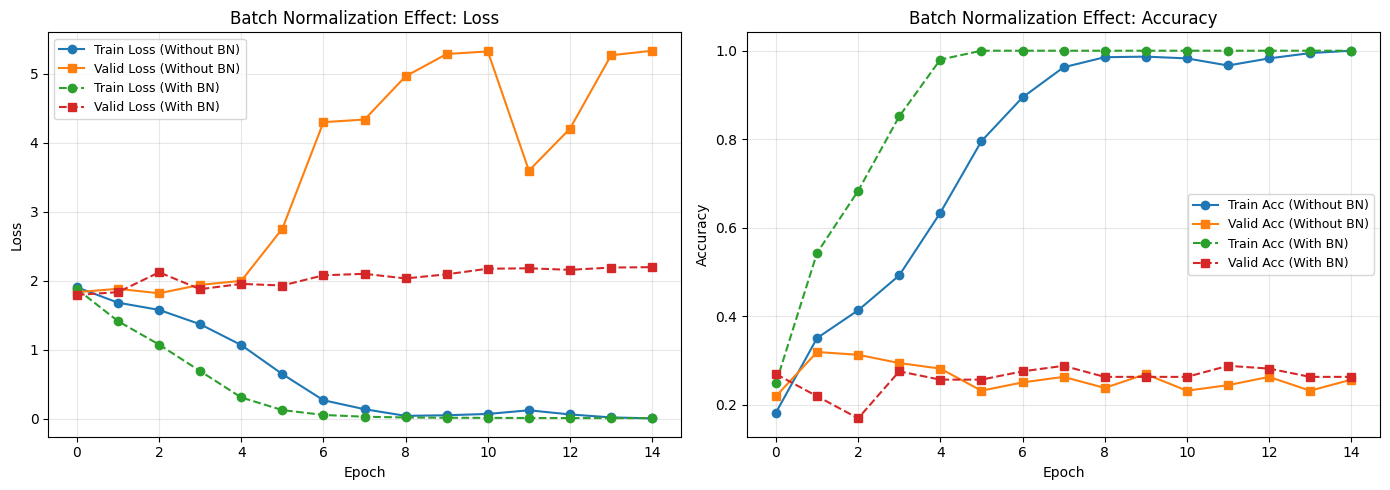

In [ ]:
# Plot BatchNorm comparison
plot_compare(history_no_bn, history_with_bn,
             label1='Without BN', label2='With BN',
             title_prefix='Batch Normalization Effect')

---
## 🛡️ Step 3 — Regularization

> **Goal:** Combat overfitting using Dropout, Weight Decay, and Data Augmentation.

In [ ]:
# ============================================================================
# STEP 3: CNN WITH REGULARIZATION
# ============================================================================

class ShallowCNN_Regularized(nn.Module):
    """
    Shallow CNN with BatchNorm and Dropout
    """
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(ShallowCNN_Regularized, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate * 0.5),  # Lower dropout for conv layers

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate * 0.5),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN_Regularized(nn.Module):
    """
    Deep CNN with BatchNorm and Dropout
    """
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(DeepCNN_Regularized, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate * 0.5),

            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate * 0.5),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Regularized architectures defined!")

Regularized architectures defined!


### 3.1 Dropout Rate Experiments

In [ ]:
# ============================================================================
# 3.1 DROPOUT RATE EXPERIMENTS
# ============================================================================

dropout_rates = [0.25, 0.5, 0.7]
dropout_histories = []

for dropout in dropout_rates:
    print(f"\n{'='*50}")
    print(f"Training with dropout rate: {dropout}")
    print(f"{'='*50}")

    model = ShallowCNN_Regularized(num_classes, dropout_rate=dropout)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    history = train_model(model, train_loader, valid_loader, optimizer,
                          num_epochs=15, verbose=False)
    dropout_histories.append(history)

    print(f"Final Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")
    print(f"Overfitting Gap: {history['train_acc'][-1] - history['valid_acc'][-1]:.4f}")


Training with dropout rate: 0.25
Final Train Acc: 0.9987
Final Valid Acc: 0.2750
Overfitting Gap: 0.7237

Training with dropout rate: 0.5
Final Train Acc: 0.6644
Final Valid Acc: 0.3000
Overfitting Gap: 0.3644

Training with dropout rate: 0.7
Final Train Acc: 0.3182
Final Valid Acc: 0.2687
Overfitting Gap: 0.0494


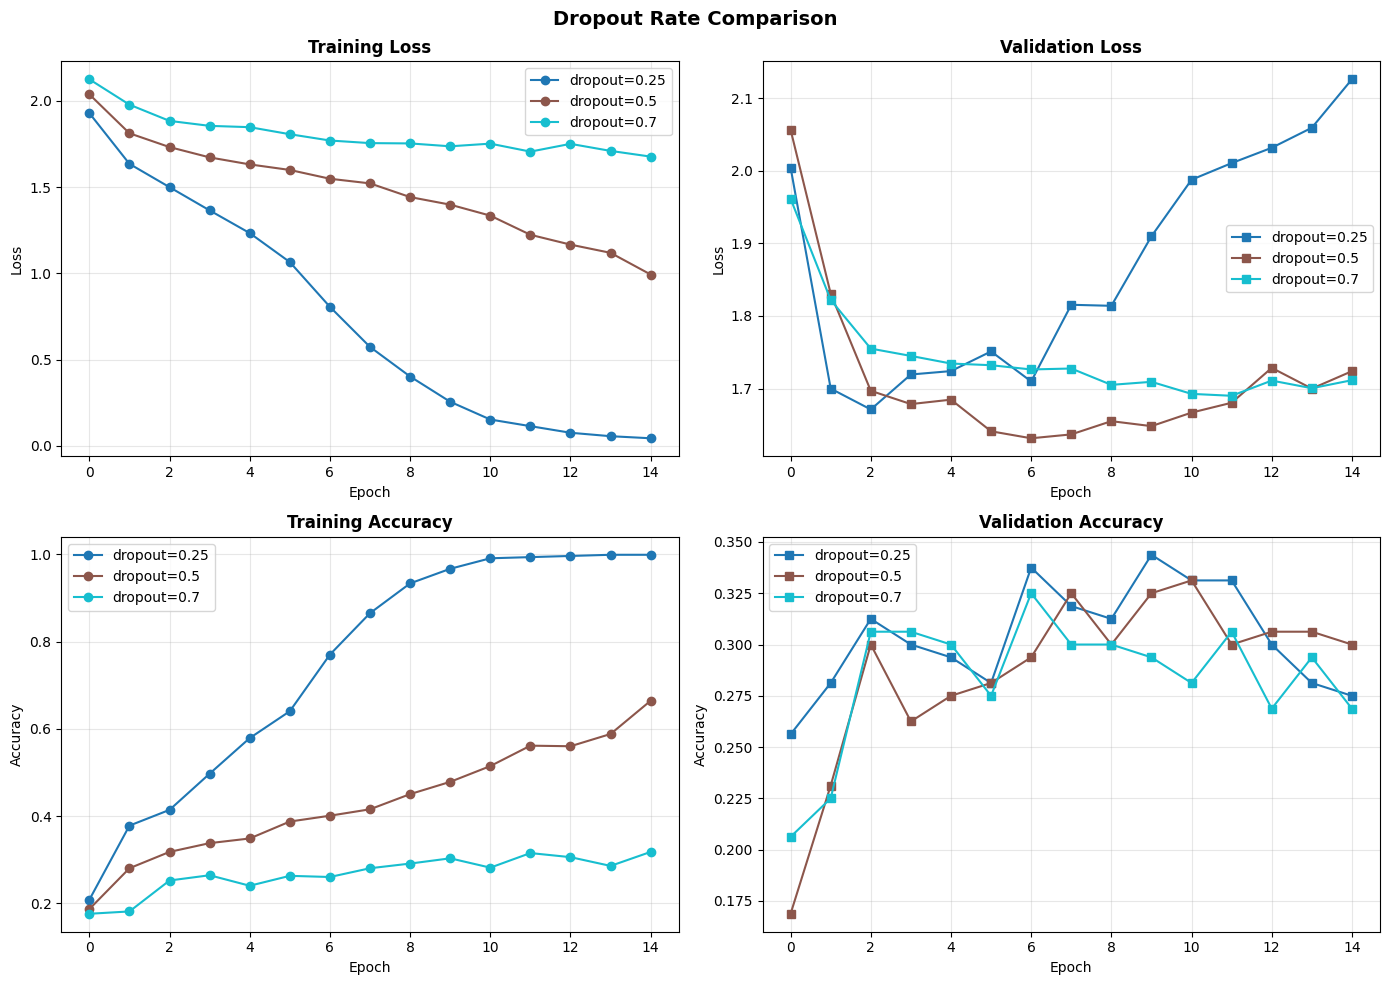

In [ ]:
# Plot dropout comparison
plot_comparison(dropout_histories, [f'dropout={d}' for d in dropout_rates],
                title="Dropout Rate Comparison")

### 3.2 Weight Decay (L2 Regularization) Experiments

In [ ]:
# ============================================================================
# 3.2 WEIGHT DECAY EXPERIMENTS
# ============================================================================

weight_decays = [1e-5, 1e-4, 1e-3, 1e-2]
wd_histories = []

for wd in weight_decays:
    print(f"\n{'='*50}")
    print(f"Training with weight decay: {wd}")
    print(f"{'='*50}")

    model = ShallowCNN_BN(num_classes)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=wd)
    history = train_model(model, train_loader, valid_loader, optimizer,
                          num_epochs=15, verbose=False)
    wd_histories.append(history)

    print(f"Final Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")


Training with weight decay: 1e-05
Final Train Acc: 1.0000
Final Valid Acc: 0.2750

Training with weight decay: 0.0001
Final Train Acc: 1.0000
Final Valid Acc: 0.3000

Training with weight decay: 0.001
Final Train Acc: 1.0000
Final Valid Acc: 0.2938

Training with weight decay: 0.01
Final Train Acc: 1.0000
Final Valid Acc: 0.3125


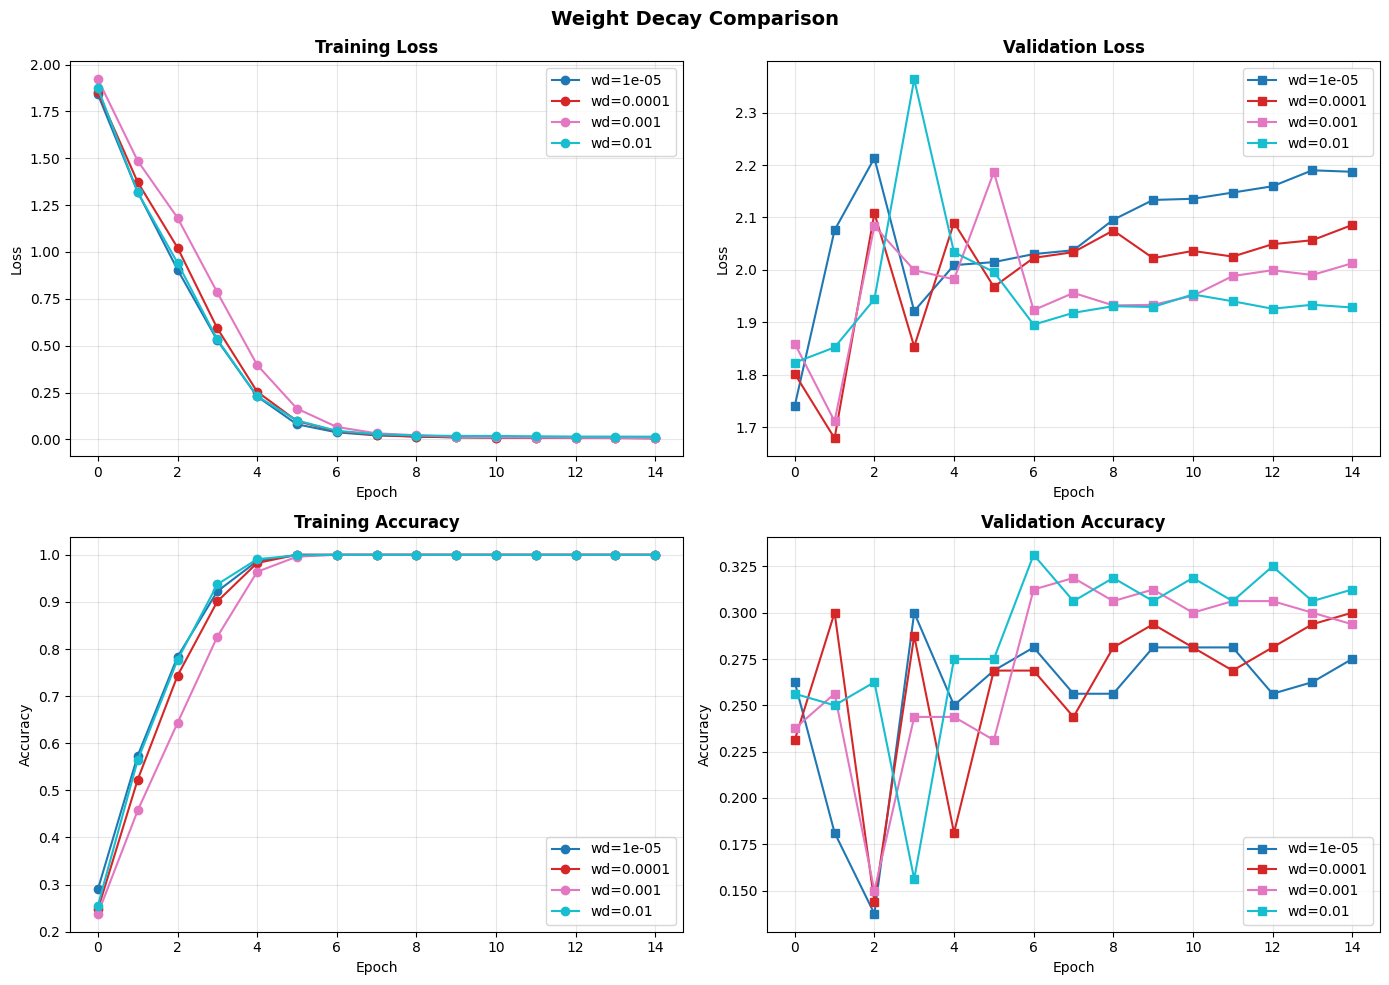

In [ ]:
# Plot weight decay comparison
plot_comparison(wd_histories, [f'wd={wd}' for wd in weight_decays],
                title="Weight Decay Comparison")

### 3.3 Data Augmentation

In [ ]:
# ============================================================================
# 3.3 DATA AUGMENTATION
# ============================================================================

# Define augmentation transforms (for training only)
train_transform_augmented = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transform (no augmentation)
valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create augmented dataset
full_dataset_aug = datasets.ImageFolder(root=DATA_PATH, transform=train_transform_augmented)
full_dataset_val = datasets.ImageFolder(root=DATA_PATH, transform=valid_transform)

# Use same split indices
train_dataset_aug = torch.utils.data.Subset(full_dataset_aug, train_dataset.indices)
valid_dataset_aug = torch.utils.data.Subset(full_dataset_val, valid_dataset.indices)

# Create DataLoaders
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_aug = DataLoader(valid_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)

print("Data augmentation transforms defined!")
print(f"Augmented training batches: {len(train_loader_aug)}")

Data augmentation transforms defined!
Augmented training batches: 12


In [ ]:
# Train with and without augmentation
print("Training WITHOUT data augmentation...")
model_no_aug = ShallowCNN_BN(num_classes)
optimizer = optim.SGD(model_no_aug.parameters(), lr=0.01, momentum=0.9)
history_no_aug = train_model(model_no_aug, train_loader, valid_loader, optimizer, num_epochs=15)

Training WITHOUT data augmentation...
Epoch [1/15] - Train Loss: 1.8923, Train Acc: 0.2299 - Valid Loss: 1.7898, Valid Acc: 0.2625
Epoch [2/15] - Train Loss: 1.3028, Train Acc: 0.5909 - Valid Loss: 1.9161, Valid Acc: 0.2000
Epoch [3/15] - Train Loss: 0.9162, Train Acc: 0.7754 - Valid Loss: 1.9549, Valid Acc: 0.2125
Epoch [4/15] - Train Loss: 0.4826, Train Acc: 0.9372 - Valid Loss: 1.8467, Valid Acc: 0.2938
Epoch [5/15] - Train Loss: 0.2006, Train Acc: 0.9933 - Valid Loss: 2.0095, Valid Acc: 0.2875
Epoch [6/15] - Train Loss: 0.0745, Train Acc: 1.0000 - Valid Loss: 1.8491, Valid Acc: 0.3187
Epoch [7/15] - Train Loss: 0.0332, Train Acc: 1.0000 - Valid Loss: 1.9050, Valid Acc: 0.3125
Epoch [8/15] - Train Loss: 0.0210, Train Acc: 1.0000 - Valid Loss: 1.9444, Valid Acc: 0.3375
Epoch [9/15] - Train Loss: 0.0148, Train Acc: 1.0000 - Valid Loss: 1.9745, Valid Acc: 0.3063
Epoch [10/15] - Train Loss: 0.0123, Train Acc: 1.0000 - Valid Loss: 1.9955, Valid Acc: 0.3063
Epoch [11/15] - Train Loss: 0.0

In [ ]:
print("\nTraining WITH data augmentation...")
model_with_aug = ShallowCNN_BN(num_classes)
optimizer = optim.SGD(model_with_aug.parameters(), lr=0.01, momentum=0.9)
history_with_aug = train_model(model_with_aug, train_loader_aug, valid_loader_aug, optimizer, num_epochs=15)


Training WITH data augmentation...
Epoch [1/15] - Train Loss: 1.9168, Train Acc: 0.2326 - Valid Loss: 1.9371, Valid Acc: 0.2000
Epoch [2/15] - Train Loss: 1.7462, Train Acc: 0.2888 - Valid Loss: 1.8169, Valid Acc: 0.2500
Epoch [3/15] - Train Loss: 1.7064, Train Acc: 0.3182 - Valid Loss: 1.7225, Valid Acc: 0.2188
Epoch [4/15] - Train Loss: 1.6194, Train Acc: 0.3757 - Valid Loss: 1.7832, Valid Acc: 0.2500
Epoch [5/15] - Train Loss: 1.6191, Train Acc: 0.3663 - Valid Loss: 1.6846, Valid Acc: 0.2625
Epoch [6/15] - Train Loss: 1.5888, Train Acc: 0.3797 - Valid Loss: 1.6770, Valid Acc: 0.2750
Epoch [7/15] - Train Loss: 1.5632, Train Acc: 0.3676 - Valid Loss: 1.6911, Valid Acc: 0.2875
Epoch [8/15] - Train Loss: 1.5278, Train Acc: 0.3930 - Valid Loss: 1.6992, Valid Acc: 0.2875
Epoch [9/15] - Train Loss: 1.5012, Train Acc: 0.4211 - Valid Loss: 1.7117, Valid Acc: 0.2812
Epoch [10/15] - Train Loss: 1.4584, Train Acc: 0.4612 - Valid Loss: 1.8181, Valid Acc: 0.2562
Epoch [11/15] - Train Loss: 1.446

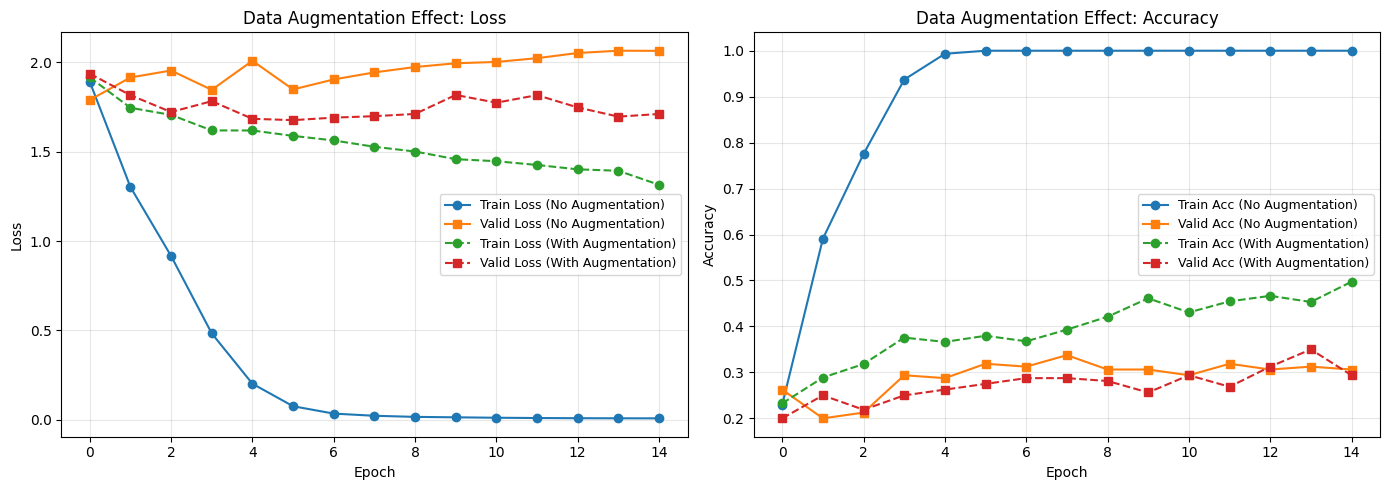

In [ ]:
# Plot augmentation comparison
plot_compare(history_no_aug, history_with_aug,
             label1='No Augmentation', label2='With Augmentation',
             title_prefix='Data Augmentation Effect')

### 3.4 Combined Regularization (Best Model Part 1)

In [ ]:
# ============================================================================
# 3.4 BEST MODEL PART 1: COMBINED REGULARIZATION
# ============================================================================

print("Training BEST MODEL (BN + Dropout + Weight Decay + Augmentation)...")

best_model_part1 = DeepCNN_Regularized(num_classes, dropout_rate=0.5)
optimizer = optim.SGD(best_model_part1.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

history_best_part1 = train_model(best_model_part1, train_loader_aug, valid_loader_aug,
                                  optimizer, num_epochs=20)

# Evaluate on test set
test_acc, predictions, labels = evaluate_model(best_model_part1, test_loader)
print(f"\n🎯 Best Model Part 1 - Test Accuracy: {test_acc:.4f}")

# Save best model
torch.save(best_model_part1.state_dict(), 'best_model_part1.pth')
print("Model saved to 'best_model_part1.pth'")

Training BEST MODEL (BN + Dropout + Weight Decay + Augmentation)...
Epoch [1/20] - Train Loss: 2.0474, Train Acc: 0.1551 - Valid Loss: 1.9504, Valid Acc: 0.1625
Epoch [2/20] - Train Loss: 1.9855, Train Acc: 0.1805 - Valid Loss: 1.9019, Valid Acc: 0.1938
Epoch [3/20] - Train Loss: 1.9419, Train Acc: 0.2086 - Valid Loss: 1.8627, Valid Acc: 0.2188
Epoch [4/20] - Train Loss: 1.9115, Train Acc: 0.2032 - Valid Loss: 1.8263, Valid Acc: 0.2687
Epoch [5/20] - Train Loss: 1.8754, Train Acc: 0.2353 - Valid Loss: 1.8206, Valid Acc: 0.2250
Epoch [6/20] - Train Loss: 1.8492, Train Acc: 0.2326 - Valid Loss: 1.7926, Valid Acc: 0.2437
Epoch [7/20] - Train Loss: 1.8342, Train Acc: 0.2233 - Valid Loss: 1.7952, Valid Acc: 0.2500
Epoch [8/20] - Train Loss: 1.8136, Train Acc: 0.2794 - Valid Loss: 1.7265, Valid Acc: 0.2437
Epoch [9/20] - Train Loss: 1.7950, Train Acc: 0.2647 - Valid Loss: 1.7374, Valid Acc: 0.2437
Epoch [10/20] - Train Loss: 1.7949, Train Acc: 0.2460 - Valid Loss: 1.7759, Valid Acc: 0.2375
E

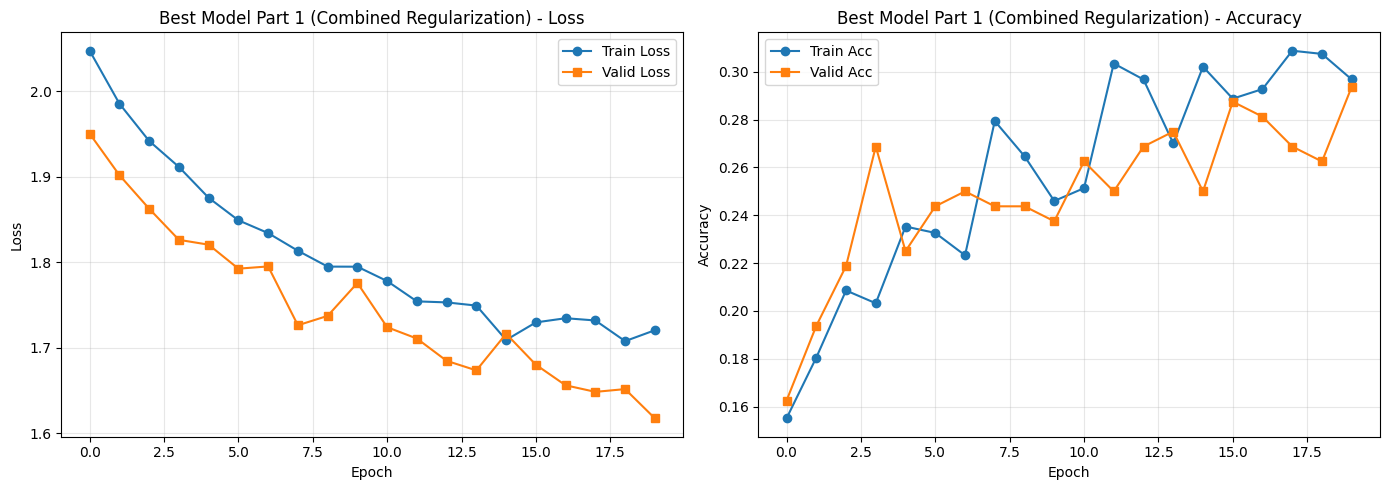

In [ ]:
# Plot best model history
plot_training_history(history_best_part1, title="Best Model Part 1 (Combined Regularization)")

---
# 📦 PART 2 — Transfer Learning (Your Own Pretrained Model)

> **Goal:** Pretrain your CNN on CIFAR-10, then fine-tune on your dataset.

## 🌐 Step 4 — Pretraining on CIFAR-10

CIFAR-10 contains 60,000 32x32 color images in 10 classes. Pretraining on this dataset helps the model learn general visual features (edges, textures, shapes) that transfer to our custom dataset.

In [ ]:
# ============================================================================
# STEP 4: LOAD AND PREPARE CIFAR-10
# ============================================================================

# CIFAR-10 transforms
cifar_transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

cifar_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Download CIFAR-10
cifar_train = datasets.CIFAR10(root='./CIFAR10', train=True, download=True, transform=cifar_transform_train)
cifar_test = datasets.CIFAR10(root='./CIFAR10', train=False, download=True, transform=cifar_transform_test)

# Split train into train/val
cifar_train_size = int(0.9 * len(cifar_train))
cifar_val_size = len(cifar_train) - cifar_train_size
cifar_train_ds, cifar_val_ds = random_split(cifar_train, [cifar_train_size, cifar_val_size],
                                             generator=torch.Generator().manual_seed(42))

# Create DataLoaders
cifar_train_loader = DataLoader(cifar_train_ds, batch_size=128, shuffle=True)
cifar_val_loader = DataLoader(cifar_val_ds, batch_size=128, shuffle=False)
cifar_test_loader = DataLoader(cifar_test, batch_size=128, shuffle=False)

print(f"CIFAR-10 Dataset:")
print(f"  Training: {len(cifar_train_ds)}")
print(f"  Validation: {len(cifar_val_ds)}")
print(f"  Test: {len(cifar_test)}")
print(f"  Classes: {cifar_train.classes}")

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


CIFAR-10 Dataset:
  Training: 45000
  Validation: 5000
  Test: 10000
  Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# ============================================================================
# CNN ARCHITECTURE FOR CIFAR-10 (32x32 images)
# ============================================================================

class CNN_CIFAR(nn.Module):
    """
    CNN adapted for CIFAR-10 (32x32 images)
    Can be transferred to larger images by modifying final layer
    """
    def __init__(self, num_classes=10):
        super(CNN_CIFAR, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 3 → 32 channels (32x32 → 16x16)
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2: 32 → 64 channels (16x16 → 8x8)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3: 64 → 128 channels (8x8 → 4x4)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv4: 128 → 256 channels (4x4 → 2x2)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print(f"CNN_CIFAR parameters: {count_parameters(CNN_CIFAR()):,}")

CNN_CIFAR parameters: 686,730


In [ ]:
# ============================================================================
# PRETRAIN ON CIFAR-10
# ============================================================================

print("Pretraining CNN on CIFAR-10...")

pretrained_model = CNN_CIFAR(num_classes=10)
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

history_cifar = train_model(pretrained_model, cifar_train_loader, cifar_val_loader,
                            optimizer, num_epochs=30, scheduler=scheduler)

# Evaluate on CIFAR-10 test set
cifar_test_acc, _, _ = evaluate_model(pretrained_model, cifar_test_loader)
print(f"\n🎯 CIFAR-10 Test Accuracy: {cifar_test_acc:.4f}")

# Save pretrained weights
torch.save(pretrained_model.state_dict(), 'pretrained_cifar10.pth')
print("Pretrained weights saved to 'pretrained_cifar10.pth'")

Pretraining CNN on CIFAR-10...
Epoch [1/30] - Train Loss: 1.5648, Train Acc: 0.4260 - Valid Loss: 1.4495, Valid Acc: 0.4856
Epoch [2/30] - Train Loss: 1.1674, Train Acc: 0.5870 - Valid Loss: 1.0513, Valid Acc: 0.6336
Epoch [3/30] - Train Loss: 1.0052, Train Acc: 0.6535 - Valid Loss: 1.0489, Valid Acc: 0.6294
Epoch [4/30] - Train Loss: 0.9088, Train Acc: 0.6894 - Valid Loss: 0.8401, Valid Acc: 0.7034
Epoch [5/30] - Train Loss: 0.8359, Train Acc: 0.7169 - Valid Loss: 0.7639, Valid Acc: 0.7282
Epoch [6/30] - Train Loss: 0.7829, Train Acc: 0.7338 - Valid Loss: 0.7252, Valid Acc: 0.7436
Epoch [7/30] - Train Loss: 0.7411, Train Acc: 0.7492 - Valid Loss: 0.6949, Valid Acc: 0.7532
Epoch [8/30] - Train Loss: 0.7071, Train Acc: 0.7630 - Valid Loss: 0.6529, Valid Acc: 0.7746
Epoch [9/30] - Train Loss: 0.6679, Train Acc: 0.7760 - Valid Loss: 0.6202, Valid Acc: 0.7844
Epoch [10/30] - Train Loss: 0.6493, Train Acc: 0.7829 - Valid Loss: 0.6225, Valid Acc: 0.7832
Epoch [11/30] - Train Loss: 0.6299, Tr

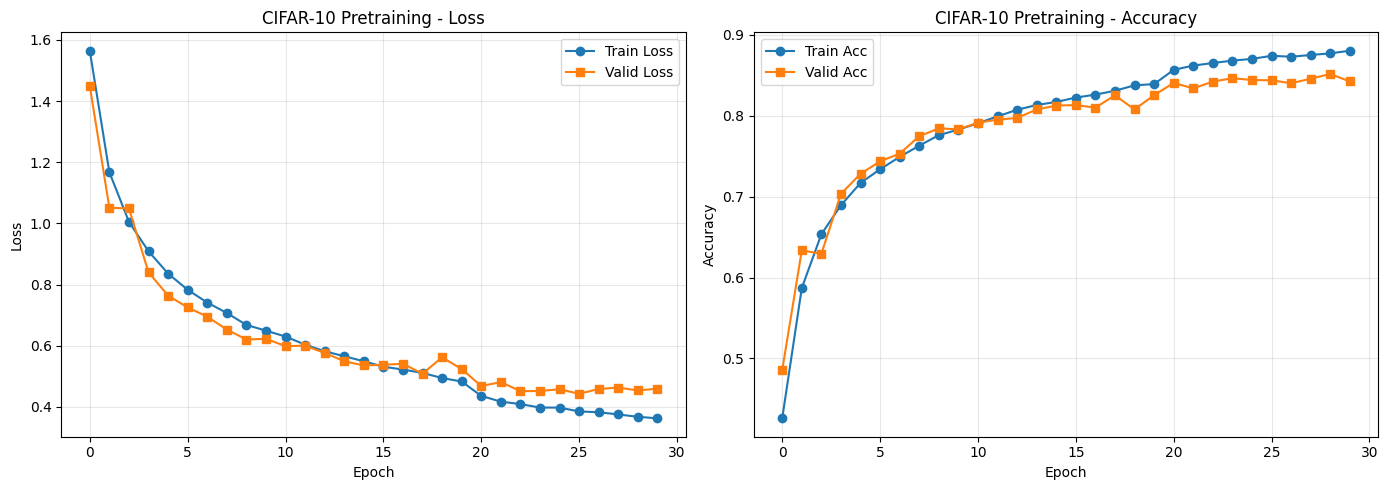

In [ ]:
# Plot CIFAR-10 pretraining results
plot_training_history(history_cifar, title="CIFAR-10 Pretraining")

## 🎯 Step 5 — Fine-Tuning on Your Dataset

In [ ]:
# ============================================================================
# STEP 5: CNN ADAPTED FOR YOUR DATASET (224x224 images)
# ============================================================================

class CNN_Transfer(nn.Module):
    """
    CNN for transfer learning from CIFAR-10 to custom dataset.
    Larger input size (224x224) with same feature extractor structure.
    """
    def __init__(self, num_classes=7):
        super(CNN_Transfer, self).__init__()

        # Same feature extractor structure as CIFAR model
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 → 112

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 → 56

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 → 28

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 → 14
        )

        # Adaptive pooling to handle different input sizes
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

print(f"CNN_Transfer parameters: {count_parameters(CNN_Transfer(num_classes)):,}")

CNN_Transfer parameters: 686,343


In [ ]:
# ============================================================================
# LOAD PRETRAINED WEIGHTS AND TRANSFER
# ============================================================================

def transfer_weights(pretrained_model, target_model):
    """Transfer weights from pretrained model to target model (feature layers only)."""
    pretrained_dict = pretrained_model.state_dict()
    target_dict = target_model.state_dict()

    # Filter out classifier weights, transfer only feature extractor weights
    transfer_dict = {}
    for key in pretrained_dict:
        if key in target_dict and 'classifier' not in key:
            if pretrained_dict[key].shape == target_dict[key].shape:
                transfer_dict[key] = pretrained_dict[key]
                print(f"  Transferred: {key}")

    target_dict.update(transfer_dict)
    target_model.load_state_dict(target_dict)
    return target_model

# Create transfer model and load pretrained weights
transfer_model = CNN_Transfer(num_classes)
print("Transferring feature extractor weights from CIFAR-10 model...")
transfer_model = transfer_weights(pretrained_model, transfer_model)
print(f"\nTransferred {len([k for k in pretrained_model.state_dict() if 'classifier' not in k])} layers")

Transferring feature extractor weights from CIFAR-10 model...
  Transferred: features.0.weight
  Transferred: features.0.bias
  Transferred: features.1.weight
  Transferred: features.1.bias
  Transferred: features.1.running_mean
  Transferred: features.1.running_var
  Transferred: features.1.num_batches_tracked
  Transferred: features.4.weight
  Transferred: features.4.bias
  Transferred: features.5.weight
  Transferred: features.5.bias
  Transferred: features.5.running_mean
  Transferred: features.5.running_var
  Transferred: features.5.num_batches_tracked
  Transferred: features.8.weight
  Transferred: features.8.bias
  Transferred: features.9.weight
  Transferred: features.9.bias
  Transferred: features.9.running_mean
  Transferred: features.9.running_var
  Transferred: features.9.num_batches_tracked
  Transferred: features.12.weight
  Transferred: features.12.bias
  Transferred: features.13.weight
  Transferred: features.13.bias
  Transferred: features.13.running_mean
  Transferred

### 5.1 Fine-tuning Experiments

In [ ]:
# ============================================================================
# EXPERIMENT 1: Fine-tune all layers
# ============================================================================

print("Experiment 1: Fine-tune ALL layers...")

model_finetune_all = CNN_Transfer(num_classes)
model_finetune_all = transfer_weights(pretrained_model, model_finetune_all)

# All layers trainable
for param in model_finetune_all.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model_finetune_all.parameters(), lr=1e-4)
history_finetune_all = train_model(model_finetune_all, train_loader_aug, valid_loader_aug,
                                    optimizer, num_epochs=15)

Experiment 1: Fine-tune ALL layers...
  Transferred: features.0.weight
  Transferred: features.0.bias
  Transferred: features.1.weight
  Transferred: features.1.bias
  Transferred: features.1.running_mean
  Transferred: features.1.running_var
  Transferred: features.1.num_batches_tracked
  Transferred: features.4.weight
  Transferred: features.4.bias
  Transferred: features.5.weight
  Transferred: features.5.bias
  Transferred: features.5.running_mean
  Transferred: features.5.running_var
  Transferred: features.5.num_batches_tracked
  Transferred: features.8.weight
  Transferred: features.8.bias
  Transferred: features.9.weight
  Transferred: features.9.bias
  Transferred: features.9.running_mean
  Transferred: features.9.running_var
  Transferred: features.9.num_batches_tracked
  Transferred: features.12.weight
  Transferred: features.12.bias
  Transferred: features.13.weight
  Transferred: features.13.bias
  Transferred: features.13.running_mean
  Transferred: features.13.running_va

In [ ]:
# ============================================================================
# EXPERIMENT 2: Freeze early layers, fine-tune later layers
# ============================================================================

print("\nExperiment 2: Freeze early conv layers, fine-tune later layers...")

model_finetune_partial = CNN_Transfer(num_classes)
model_finetune_partial = transfer_weights(pretrained_model, model_finetune_partial)

# Freeze first 2 conv blocks (features[0:8])
for i, (name, param) in enumerate(model_finetune_partial.features.named_parameters()):
    if i < 8:  # First 2 conv blocks
        param.requires_grad = False
        print(f"  Frozen: features.{name}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_finetune_partial.parameters()), lr=1e-3)
history_finetune_partial = train_model(model_finetune_partial, train_loader_aug, valid_loader_aug,
                                        optimizer, num_epochs=15)


Experiment 2: Freeze early conv layers, fine-tune later layers...
  Transferred: features.0.weight
  Transferred: features.0.bias
  Transferred: features.1.weight
  Transferred: features.1.bias
  Transferred: features.1.running_mean
  Transferred: features.1.running_var
  Transferred: features.1.num_batches_tracked
  Transferred: features.4.weight
  Transferred: features.4.bias
  Transferred: features.5.weight
  Transferred: features.5.bias
  Transferred: features.5.running_mean
  Transferred: features.5.running_var
  Transferred: features.5.num_batches_tracked
  Transferred: features.8.weight
  Transferred: features.8.bias
  Transferred: features.9.weight
  Transferred: features.9.bias
  Transferred: features.9.running_mean
  Transferred: features.9.running_var
  Transferred: features.9.num_batches_tracked
  Transferred: features.12.weight
  Transferred: features.12.bias
  Transferred: features.13.weight
  Transferred: features.13.bias
  Transferred: features.13.running_mean
  Transf

In [ ]:
# ============================================================================
# EXPERIMENT 3: Train from scratch (for comparison)
# ============================================================================

print("\nExperiment 3: Train from scratch (no pretraining)...")

model_from_scratch = CNN_Transfer(num_classes)
# No weight transfer - random initialization

optimizer = optim.Adam(model_from_scratch.parameters(), lr=1e-3)
history_from_scratch = train_model(model_from_scratch, train_loader_aug, valid_loader_aug,
                                    optimizer, num_epochs=15)


Experiment 3: Train from scratch (no pretraining)...
Epoch [1/15] - Train Loss: 2.0542, Train Acc: 0.1591 - Valid Loss: 1.9138, Valid Acc: 0.1875
Epoch [2/15] - Train Loss: 1.9583, Train Acc: 0.1885 - Valid Loss: 1.8281, Valid Acc: 0.2313
Epoch [3/15] - Train Loss: 1.9250, Train Acc: 0.2166 - Valid Loss: 1.8352, Valid Acc: 0.1938
Epoch [4/15] - Train Loss: 1.8676, Train Acc: 0.2353 - Valid Loss: 1.8415, Valid Acc: 0.1938
Epoch [5/15] - Train Loss: 1.8548, Train Acc: 0.2326 - Valid Loss: 2.0598, Valid Acc: 0.1375
Epoch [6/15] - Train Loss: 1.7945, Train Acc: 0.2540 - Valid Loss: 1.9001, Valid Acc: 0.1750
Epoch [7/15] - Train Loss: 1.8013, Train Acc: 0.2848 - Valid Loss: 1.9009, Valid Acc: 0.1750
Epoch [8/15] - Train Loss: 1.8079, Train Acc: 0.2741 - Valid Loss: 1.8185, Valid Acc: 0.1750
Epoch [9/15] - Train Loss: 1.7679, Train Acc: 0.2660 - Valid Loss: 1.7523, Valid Acc: 0.2375
Epoch [10/15] - Train Loss: 1.7429, Train Acc: 0.2874 - Valid Loss: 1.9009, Valid Acc: 0.2500
Epoch [11/15] -

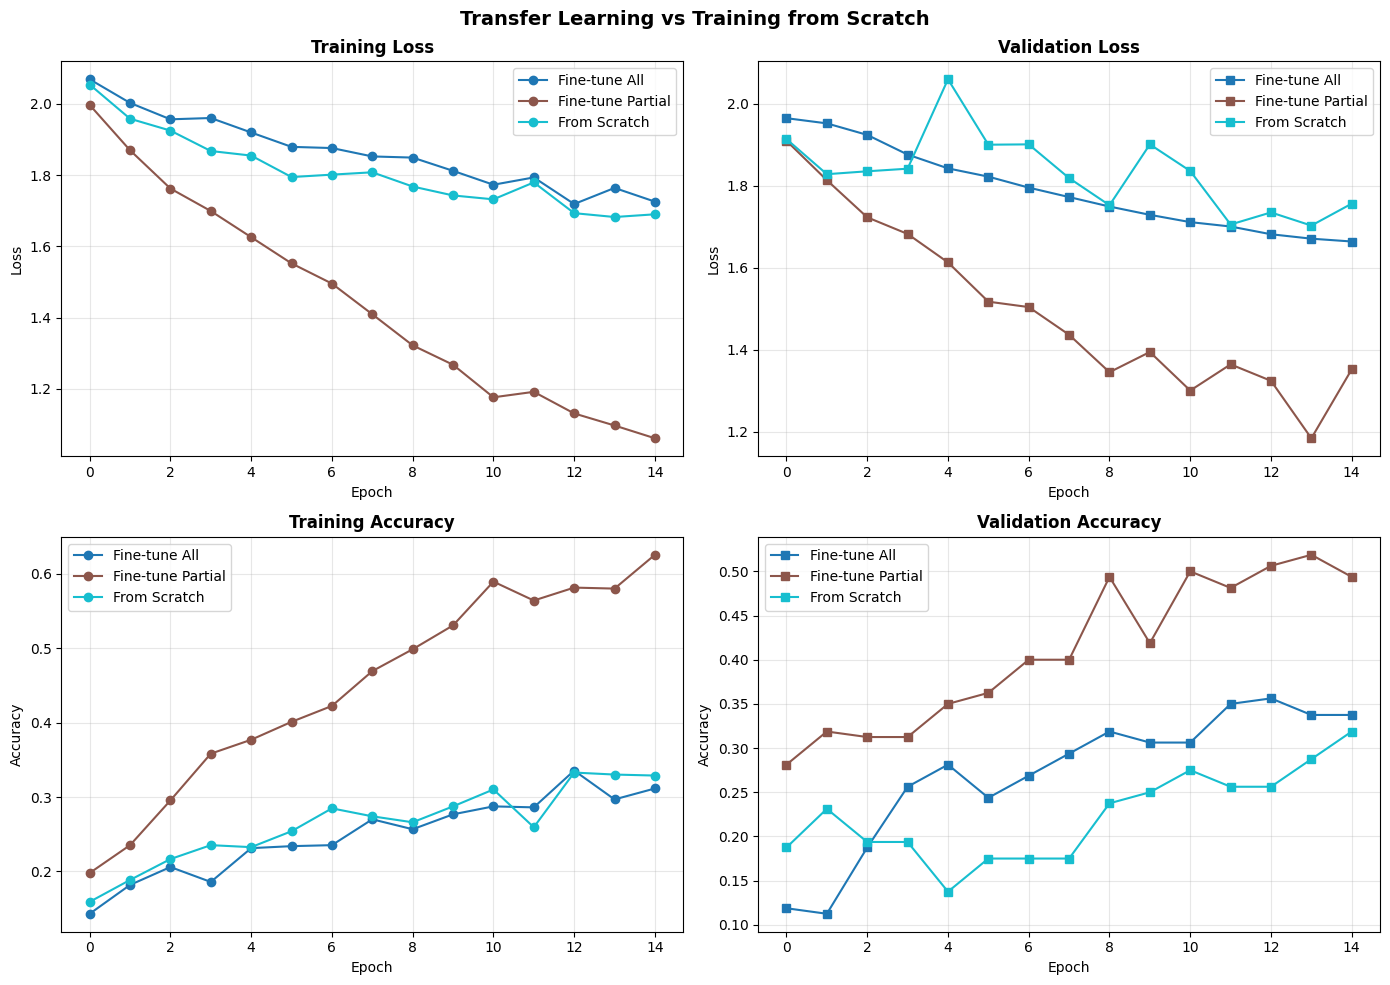


TEST SET EVALUATION
Fine-tune All Layers:    0.3602
Fine-tune Partial:       0.5155
From Scratch:            0.2609


In [ ]:
# ============================================================================
# COMPARE TRANSFER LEARNING VS FROM SCRATCH
# ============================================================================

# Plot comparison
plot_comparison(
    [history_finetune_all, history_finetune_partial, history_from_scratch],
    ['Fine-tune All', 'Fine-tune Partial', 'From Scratch'],
    title="Transfer Learning vs Training from Scratch"
)

# Evaluate all models on test set
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

test_acc_all, _, _ = evaluate_model(model_finetune_all, test_loader)
test_acc_partial, _, _ = evaluate_model(model_finetune_partial, test_loader)
test_acc_scratch, _, _ = evaluate_model(model_from_scratch, test_loader)

print(f"Fine-tune All Layers:    {test_acc_all:.4f}")
print(f"Fine-tune Partial:       {test_acc_partial:.4f}")
print(f"From Scratch:            {test_acc_scratch:.4f}")

---
# 📦 PART 3 — Transfer Learning with ResNet50

> **Goal:** Leverage ImageNet-pretrained ResNet50 for maximum performance.

## 🏗️ Step 6 — Adapting ResNet50

In [ ]:
# ============================================================================
# STEP 6: LOAD AND ADAPT RESNET50
# ============================================================================

def create_resnet50(num_classes, freeze_features=True):
    """
    Create ResNet50 model with modified final layer.

    Args:
        num_classes: Number of output classes
        freeze_features: If True, freeze all feature layers
    """
    # Load pretrained ResNet50
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Freeze feature layers if specified
    if freeze_features:
        for param in resnet.parameters():
            param.requires_grad = False

    # Replace final fully connected layer
    num_features = resnet.fc.in_features  # 2048
    resnet.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return resnet

# Create model and explore architecture
resnet50_model = create_resnet50(num_classes, freeze_features=True)
print("ResNet50 Architecture (modified):")
print(f"Total parameters: {count_parameters(resnet50_model):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet50_model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


ResNet50 Architecture (modified):
Total parameters: 1,052,679
Trainable parameters: 1,052,679


## 🎓 Step 7 — Training & Fine-Tuning ResNet50

In [ ]:
# ============================================================================
# EXPERIMENT 1: Feature Extraction Only (freeze all except FC)
# ============================================================================

print("ResNet50 Experiment 1: Feature Extraction (frozen features)...")

resnet_frozen = create_resnet50(num_classes, freeze_features=True)
optimizer = optim.Adam(resnet_frozen.fc.parameters(), lr=1e-3)

history_resnet_frozen = train_model(resnet_frozen, train_loader_aug, valid_loader_aug,
                                     optimizer, num_epochs=10)

ResNet50 Experiment 1: Feature Extraction (frozen features)...
Epoch [1/10] - Train Loss: 1.3287, Train Acc: 0.6551 - Valid Loss: 0.5283, Valid Acc: 0.9313
Epoch [2/10] - Train Loss: 0.3894, Train Acc: 0.9198 - Valid Loss: 0.2337, Valid Acc: 0.9187
Epoch [3/10] - Train Loss: 0.2077, Train Acc: 0.9291 - Valid Loss: 0.1381, Valid Acc: 0.9563
Epoch [4/10] - Train Loss: 0.1614, Train Acc: 0.9532 - Valid Loss: 0.1340, Valid Acc: 0.9500
Epoch [5/10] - Train Loss: 0.1146, Train Acc: 0.9679 - Valid Loss: 0.1154, Valid Acc: 0.9500
Epoch [6/10] - Train Loss: 0.0988, Train Acc: 0.9733 - Valid Loss: 0.1542, Valid Acc: 0.9437
Epoch [7/10] - Train Loss: 0.0714, Train Acc: 0.9799 - Valid Loss: 0.1276, Valid Acc: 0.9500
Epoch [8/10] - Train Loss: 0.0656, Train Acc: 0.9799 - Valid Loss: 0.1297, Valid Acc: 0.9500
Epoch [9/10] - Train Loss: 0.0566, Train Acc: 0.9853 - Valid Loss: 0.1133, Valid Acc: 0.9500
Epoch [10/10] - Train Loss: 0.0419, Train Acc: 0.9960 - Valid Loss: 0.1336, Valid Acc: 0.9500

Total

In [ ]:
# ============================================================================
# EXPERIMENT 2: Partial Fine-tuning (unfreeze layer4)
# ============================================================================

print("\nResNet50 Experiment 2: Partial Fine-tuning (unfreeze layer4)...")

resnet_partial = create_resnet50(num_classes, freeze_features=True)

# Unfreeze layer4
for param in resnet_partial.layer4.parameters():
    param.requires_grad = True

print(f"Trainable parameters after unfreezing layer4: {sum(p.numel() for p in resnet_partial.parameters() if p.requires_grad):,}")

optimizer = optim.Adam([
    {'params': resnet_partial.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_partial.fc.parameters(), 'lr': 1e-3}
])

history_resnet_partial = train_model(resnet_partial, train_loader_aug, valid_loader_aug,
                                      optimizer, num_epochs=15)


ResNet50 Experiment 2: Partial Fine-tuning (unfreeze layer4)...
Trainable parameters after unfreezing layer4: 16,017,415
Epoch [1/15] - Train Loss: 1.1390, Train Acc: 0.6858 - Valid Loss: 0.1555, Valid Acc: 0.9750
Epoch [2/15] - Train Loss: 0.2106, Train Acc: 0.9385 - Valid Loss: 0.1481, Valid Acc: 0.9500
Epoch [3/15] - Train Loss: 0.1308, Train Acc: 0.9559 - Valid Loss: 0.0862, Valid Acc: 0.9625
Epoch [4/15] - Train Loss: 0.0605, Train Acc: 0.9813 - Valid Loss: 0.0777, Valid Acc: 0.9750
Epoch [5/15] - Train Loss: 0.0453, Train Acc: 0.9853 - Valid Loss: 0.0724, Valid Acc: 0.9750
Epoch [6/15] - Train Loss: 0.0357, Train Acc: 0.9906 - Valid Loss: 0.0584, Valid Acc: 0.9750
Epoch [7/15] - Train Loss: 0.0280, Train Acc: 0.9920 - Valid Loss: 0.0859, Valid Acc: 0.9750
Epoch [8/15] - Train Loss: 0.0112, Train Acc: 0.9987 - Valid Loss: 0.0756, Valid Acc: 0.9812
Epoch [9/15] - Train Loss: 0.0302, Train Acc: 0.9920 - Valid Loss: 0.0958, Valid Acc: 0.9750
Epoch [10/15] - Train Loss: 0.0141, Train

In [ ]:
# ============================================================================
# EXPERIMENT 3: Full Fine-tuning (unfreeze all)
# ============================================================================

print("\nResNet50 Experiment 3: Full Fine-tuning...")

resnet_full = create_resnet50(num_classes, freeze_features=False)

# Differential learning rates
optimizer = optim.Adam([
    {'params': resnet_full.conv1.parameters(), 'lr': 1e-5},
    {'params': resnet_full.bn1.parameters(), 'lr': 1e-5},
    {'params': resnet_full.layer1.parameters(), 'lr': 1e-5},
    {'params': resnet_full.layer2.parameters(), 'lr': 5e-5},
    {'params': resnet_full.layer3.parameters(), 'lr': 1e-4},
    {'params': resnet_full.layer4.parameters(), 'lr': 5e-4},
    {'params': resnet_full.fc.parameters(), 'lr': 1e-3}
])

history_resnet_full = train_model(resnet_full, train_loader_aug, valid_loader_aug,
                                   optimizer, num_epochs=15)


ResNet50 Experiment 3: Full Fine-tuning...
Epoch [1/15] - Train Loss: 0.8445, Train Acc: 0.7527 - Valid Loss: 0.1950, Valid Acc: 0.9625
Epoch [2/15] - Train Loss: 0.1641, Train Acc: 0.9492 - Valid Loss: 0.2881, Valid Acc: 0.9313
Epoch [3/15] - Train Loss: 0.0964, Train Acc: 0.9693 - Valid Loss: 0.3557, Valid Acc: 0.9062
Epoch [4/15] - Train Loss: 0.0917, Train Acc: 0.9746 - Valid Loss: 0.3931, Valid Acc: 0.9000
Epoch [5/15] - Train Loss: 0.0915, Train Acc: 0.9719 - Valid Loss: 0.4870, Valid Acc: 0.9187
Epoch [6/15] - Train Loss: 0.0736, Train Acc: 0.9826 - Valid Loss: 0.1734, Valid Acc: 0.9625
Epoch [7/15] - Train Loss: 0.0535, Train Acc: 0.9893 - Valid Loss: 0.2040, Valid Acc: 0.9375
Epoch [8/15] - Train Loss: 0.0212, Train Acc: 0.9947 - Valid Loss: 0.1376, Valid Acc: 0.9500
Epoch [9/15] - Train Loss: 0.0143, Train Acc: 0.9960 - Valid Loss: 0.1633, Valid Acc: 0.9500
Epoch [10/15] - Train Loss: 0.0177, Train Acc: 0.9947 - Valid Loss: 0.1645, Valid Acc: 0.9563
Epoch [11/15] - Train Los

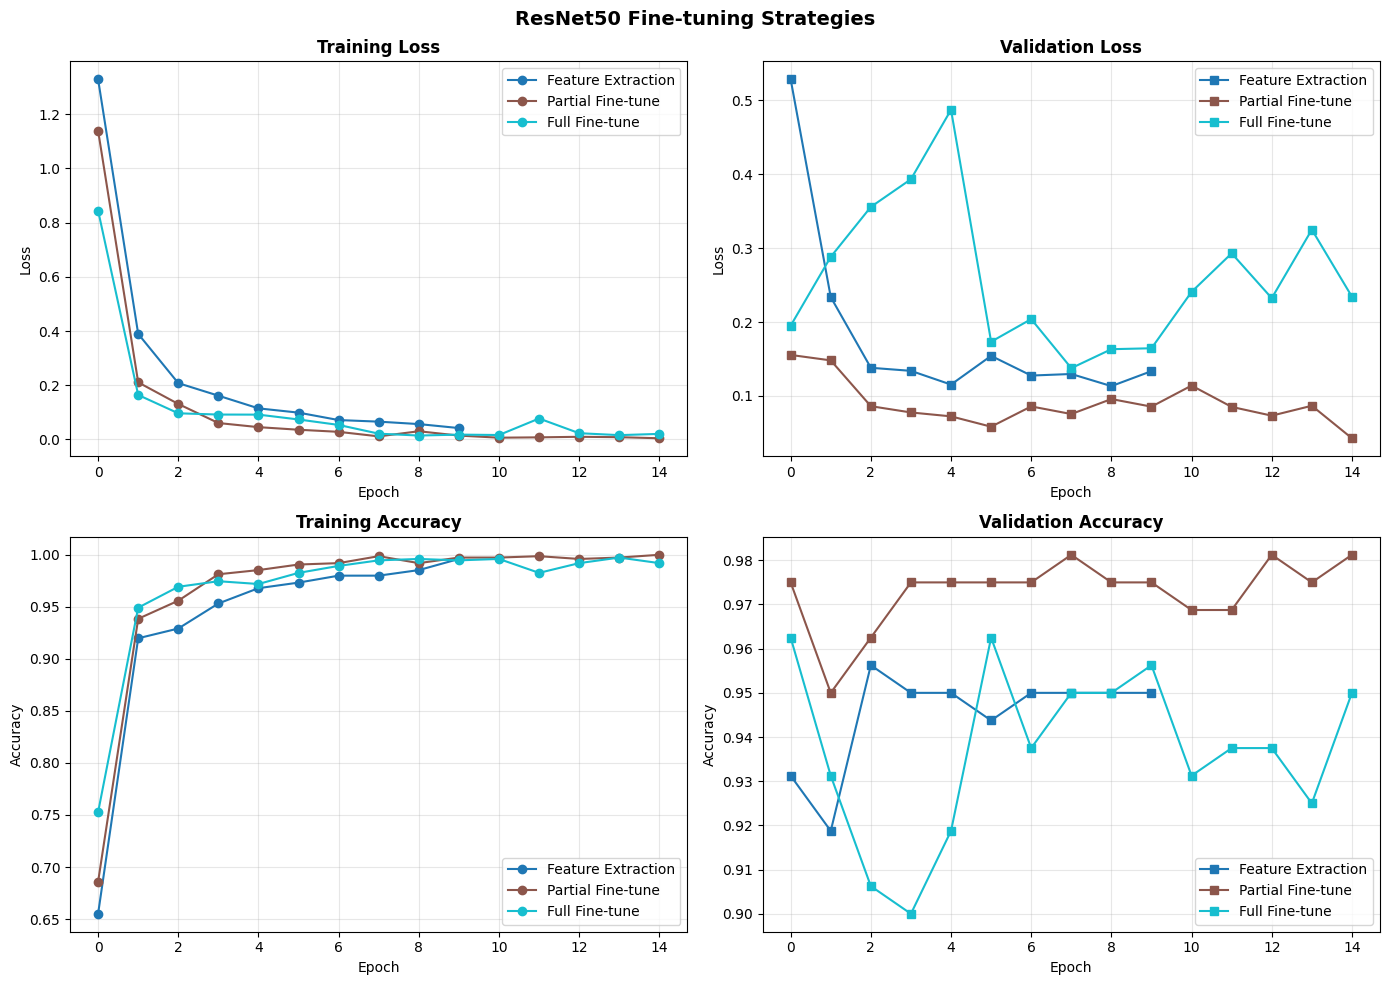

In [ ]:
# Plot ResNet50 experiments comparison
plot_comparison(
    [history_resnet_frozen, history_resnet_partial, history_resnet_full],
    ['Feature Extraction', 'Partial Fine-tune', 'Full Fine-tune'],
    title="ResNet50 Fine-tuning Strategies"
)

---
# 📊 Final Results & Comparison

In [ ]:
# ============================================================================
# FINAL MODEL EVALUATION ON TEST SET
# ============================================================================

print("="*60)
print("FINAL TEST SET EVALUATION - ALL MODELS")
print("="*60)

# Evaluate all models
models_to_evaluate = [
    ("Part 1: Best CNN (from scratch)", best_model_part1),
    ("Part 2: Transfer (Fine-tune All)", model_finetune_all),
    ("Part 2: Transfer (Partial)", model_finetune_partial),
    ("Part 2: From Scratch", model_from_scratch),
    ("Part 3: ResNet50 (Feature Extract)", resnet_frozen),
    ("Part 3: ResNet50 (Partial Fine-tune)", resnet_partial),
    ("Part 3: ResNet50 (Full Fine-tune)", resnet_full),
]

results = []
for name, model in models_to_evaluate:
    acc, _, _ = evaluate_model(model, test_loader)
    results.append((name, acc))
    print(f"{name}: {acc:.4f}")

print("\n" + "="*60)
print("BEST MODEL:")
best_model_name, best_acc = max(results, key=lambda x: x[1])
print(f"  {best_model_name} with accuracy: {best_acc:.4f}")
print("="*60)

FINAL TEST SET EVALUATION - ALL MODELS
Part 1: Best CNN (from scratch): 0.3727
Part 2: Transfer (Fine-tune All): 0.3602
Part 2: Transfer (Partial): 0.5155
Part 2: From Scratch: 0.2609
Part 3: ResNet50 (Feature Extract): 0.9503
Part 3: ResNet50 (Partial Fine-tune): 0.9379
Part 3: ResNet50 (Full Fine-tune): 0.9255

BEST MODEL:
  Part 3: ResNet50 (Feature Extract) with accuracy: 0.9503


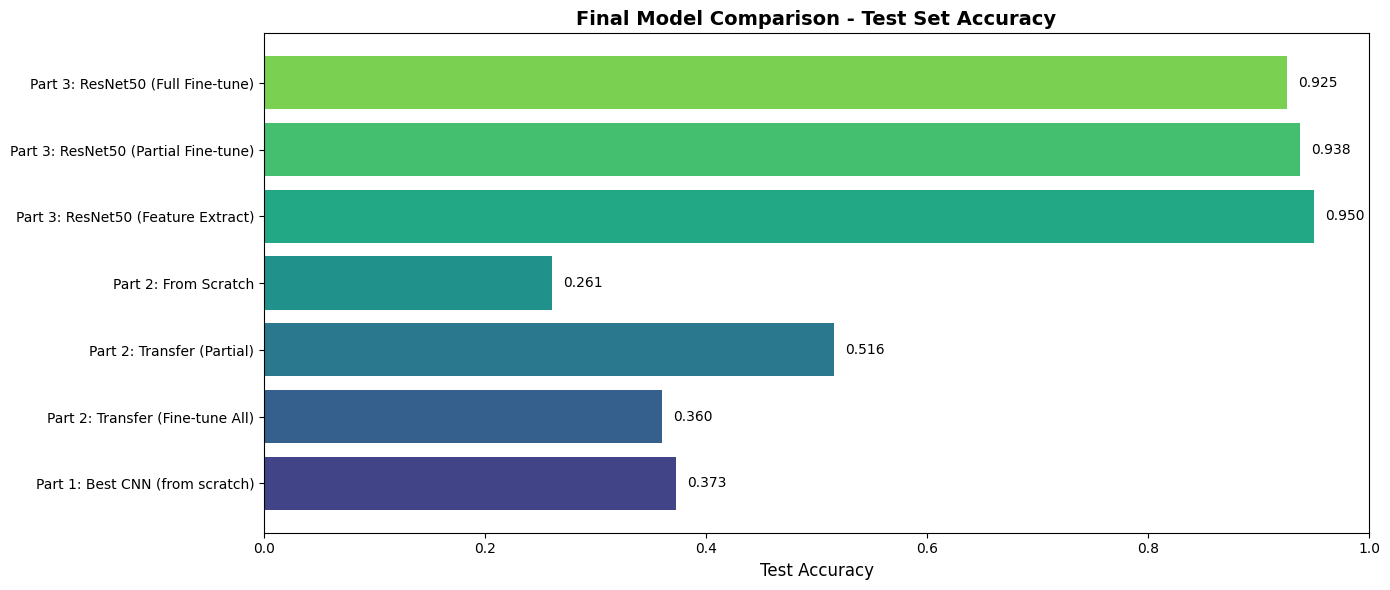

In [ ]:
# ============================================================================
# VISUALIZATION: COMPARISON BAR CHART
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

names = [r[0] for r in results]
accs = [r[1] for r in results]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results)))

bars = ax.barh(names, accs, color=colors)
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Final Model Comparison - Test Set Accuracy', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)

# Add value labels
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.3f}',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 📝 Summary & Conclusions

### Part 1: Training from Scratch
- Compared shallow (2 conv) vs deep (4 conv) architectures
- Adam and SGD optimizers show different convergence patterns
- Batch Normalization improves training stability
- Regularization (Dropout + Weight Decay + Augmentation) reduces overfitting

### Part 2: Transfer Learning (Own Pretrained Model)
- Pretraining on CIFAR-10 learns general visual features
- Fine-tuning with frozen early layers often works well
- Transfer learning typically converges faster than training from scratch

### Part 3: Transfer Learning with ResNet50
- ImageNet-pretrained ResNet50 provides excellent feature extraction
- Feature extraction alone (frozen layers) can achieve good results quickly
- Partial fine-tuning with differential learning rates balances stability and adaptation
- Full fine-tuning with very low learning rates for early layers prevents catastrophic forgetting

In [ ]:
# ============================================================================
# SAVE BEST MODEL
# ============================================================================

# Find and save the best performing model
best_idx = max(range(len(results)), key=lambda i: results[i][1])
best_name, best_model = models_to_evaluate[best_idx][0], models_to_evaluate[best_idx][1]

torch.save(best_model.state_dict(), 'best_final_model.pth')
print(f"Best model '{best_name}' saved to 'best_final_model.pth'")
print(f"Test Accuracy: {results[best_idx][1]:.4f}")

Best model 'Part 3: ResNet50 (Feature Extract)' saved to 'best_final_model.pth'
Test Accuracy: 0.9503
